# Dictionaries

In [1]:
# --- Standard Imports
import os
from pathlib import Path
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import plotly.express as px
import geopandas as gpd

# Import Customers and Flights Clean Datasets

In [2]:
# directory with raw CSV files
data_dir = Path("../data/cleaned")

# list all CSV files
csv_files = list(data_dir.glob("*.csv"))
print(f"Found CSV files: {[f.name for f in csv_files]}")

Found CSV files: ['customers_cleaned.csv', 'flights_cleaned.csv']


In [3]:
# specify the files we want to load
customers_file = data_dir / "customers_cleaned.csv"
flights_file   = data_dir / "flights_cleaned.csv"

# load them with pandas
customers = pd.read_csv(customers_file)
flights   = pd.read_csv(flights_file)

print("Customers shape:", customers.shape)
print("Flights shape:", flights.shape)

Customers shape: (16574, 21)
Flights shape: (596664, 10)


## Number of customers by City

C:\Users\Duarte\AppData\Local\Temp\ipykernel_14280\2863074747.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=city_counts, x="City", y="Count", palette="viridis")


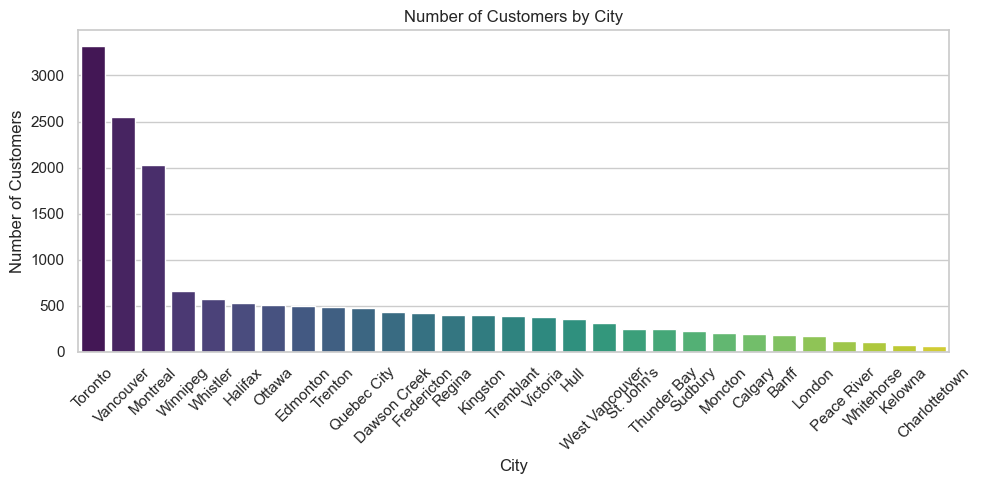

In [4]:
# Set style
sns.set(style="whitegrid")

# Calculate counts per city and sort descending
city_counts = customers["City"].value_counts().reset_index()
city_counts.columns = ["City", "Count"]

# Create bar chart ordered by number of customers
plt.figure(figsize=(10, 5))
sns.barplot(data=city_counts, x="City", y="Count", palette="viridis")

plt.title("Number of Customers by City")
plt.xlabel("City")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Import the Agregated dataset

In [5]:
# directory with agregated dataset
data_dir = Path("../data/aggregated/")

# list all CSV files
csv_files = list(data_dir.glob("*.csv"))
print(f"Found CSV files: {[f.name for f in csv_files]}")


Found CSV files: ['customers_aggregations.csv']


In [6]:
# specify the files we want to load
dataset = data_dir / "customers_aggregations.csv"

# load them with pandas
dataset = pd.read_csv(dataset)

print("dataset shape:", dataset.shape)

dataset shape: (16574, 31)


In [7]:
# display the first few rows of the dataframe
display(dataset.head(3))

,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,...,EndDate,CustomerTenureDays,total_flights,total_flights_with_companions,total_distance,total_points_accumulated,total_points_redeemed,total_cost_redeemed,points_redemption_ratio,companion_flight_ratio
0,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,...,2025-10-13,2432,216,53,507054.9,50699.39,13517.9,134.6,0.266628,0.245370
1,549612,Dayle,Menez,Dayle Menez,Canada,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,...,2025-10-13,2410,286,30,426827.4,42672.54,22457.8,221.4,0.526282,0.104895
2,429460,Necole,Hannon,Necole Hannon,Canada,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,...,2021-01-08,1274,143,37,238376.1,23832.41,5479.6,53.2,0.229922,0.258741


In [8]:
# Display basic info
print("\nFlightsDB basic info:")
print(dataset.info())


FlightsDB basic info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16574 entries, 0 to 16573
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Loyalty#                       16574 non-null  int64  
 1   First Name                     16574 non-null  object 
 2   Last Name                      16574 non-null  object 
 3   Customer Name                  16574 non-null  object 
 4   Country                        16574 non-null  object 
 5   Province or State              16574 non-null  object 
 6   City                           16574 non-null  object 
 7   Latitude                       16574 non-null  float64
 8   Longitude                      16574 non-null  float64
 9   Postal code                    16574 non-null  object 
 10  Gender                         16574 non-null  object 
 11  Education                      16574 non-null  object 
 12  Location Code          

In [9]:
dataset.columns

Index(['Loyalty#', 'First Name', 'Last Name', 'Customer Name', 'Country',
       'Province or State', 'City', 'Latitude', 'Longitude', 'Postal code',
       'Gender', 'Education', 'Location Code', 'Income', 'Marital Status',
       'LoyaltyStatus', 'EnrollmentDateOpening', 'CancellationDate',
       'Customer Lifetime Value', 'EnrollmentType', 'IsActive', 'EndDate',
       'CustomerTenureDays', 'total_flights', 'total_flights_with_companions',
       'total_distance', 'total_points_accumulated', 'total_points_redeemed',
       'total_cost_redeemed', 'points_redemption_ratio',
       'companion_flight_ratio'],
      dtype='object')

In [10]:
# Basic Descriptive Statistics
dataset.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Loyalty#,16574.0,NaN,NaN,NaN,549435.680825,258874.788435,100018.0,326235.5,550020.0,771895.75,999986.0
First Name,16574,4926,Deon,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Last Name,16574,15116,Salberg,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,16574,16574,Ariane Peyton,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,16574,1,Canada,16574,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Province or State,16574,11,Ontario,5354,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,16574,29,Toronto,3323,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitude,16574.0,NaN,NaN,NaN,47.174633,3.305623,42.984924,44.231171,46.087818,49.28273,60.721188
Longitude,16574.0,NaN,NaN,NaN,-91.840494,22.240412,-135.05684,-120.23766,-79.383186,-74.596184,-52.712578
Postal code,16574,55,V6E 3D9,906,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Income Analysis

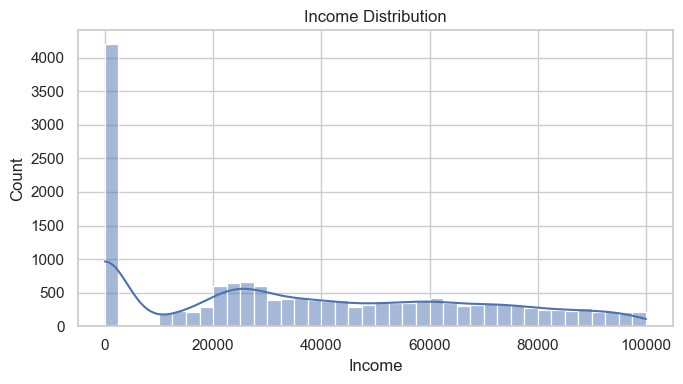

Income summary:
          Income
count  16574.00
mean   37739.99
std    30355.91
min        0.00
10%        0.00
25%        0.00
50%    34137.00
75%    62373.75
90%    81946.40
95%    90330.00
max    99981.00


In [11]:
# Income distribution

plt.figure(figsize=(7,4))
sns.histplot(dataset["Income"].dropna(), bins=40, kde=True)
plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

desc = dataset["Income"].describe(percentiles=[.1,.25,.5,.75,.9,.95]).to_frame("Income").round(2)
print("Income summary:\n", desc)

## Zero_Income Analysis. We have a big number of customers with no income, Why is that?

In [12]:
zero_income = dataset[dataset["Income"] == 0]
"""customer with income = 0"""

'customer with income = 0'

In [13]:
print("=== Gender ===")
print(zero_income["Gender"].value_counts())
print("\n=== Marital Status ===")
print(zero_income["Marital Status"].value_counts())
print("\n=== Education ===")
print(zero_income["Education"].value_counts())

=== Gender ===
Gender
male      2137
female    2061
Name: count, dtype: int64

=== Marital Status ===
Marital Status
Single      2403
Married     1425
Divorced     370
Name: count, dtype: int64

=== Education ===
Education
College    4198
Name: count, dtype: int64


In [14]:
print("=== Location Code ===")
print(zero_income["Location Code"].value_counts())
print("\n=== EnrollmentType ===")
print(zero_income["EnrollmentType"].value_counts())
print("\n=== LoyaltyStatus ===")
print(zero_income["LoyaltyStatus"].value_counts())

=== Location Code ===
Location Code
Rural       1422
Urban       1406
Suburban    1370
Name: count, dtype: int64

=== EnrollmentType ===
EnrollmentType
Standard          3913
2021 Promotion     285
Name: count, dtype: int64

=== LoyaltyStatus ===
LoyaltyStatus
Star      2096
Nova      1319
Aurora     783
Name: count, dtype: int64


C:\Users\Duarte\AppData\Local\Temp\ipykernel_14280\1366238634.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=zero_income, x="Gender", palette="Set2", ax=axes[0, 0])
C:\Users\Duarte\AppData\Local\Temp\ipykernel_14280\1366238634.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=zero_income, x="Marital Status", palette="Set3", ax=axes[0, 1])
C:\Users\Duarte\AppData\Local\Temp\ipykernel_14280\1366238634.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=zero_income, x="Education", palette="Set1", ax=axes[0, 2])
C:\

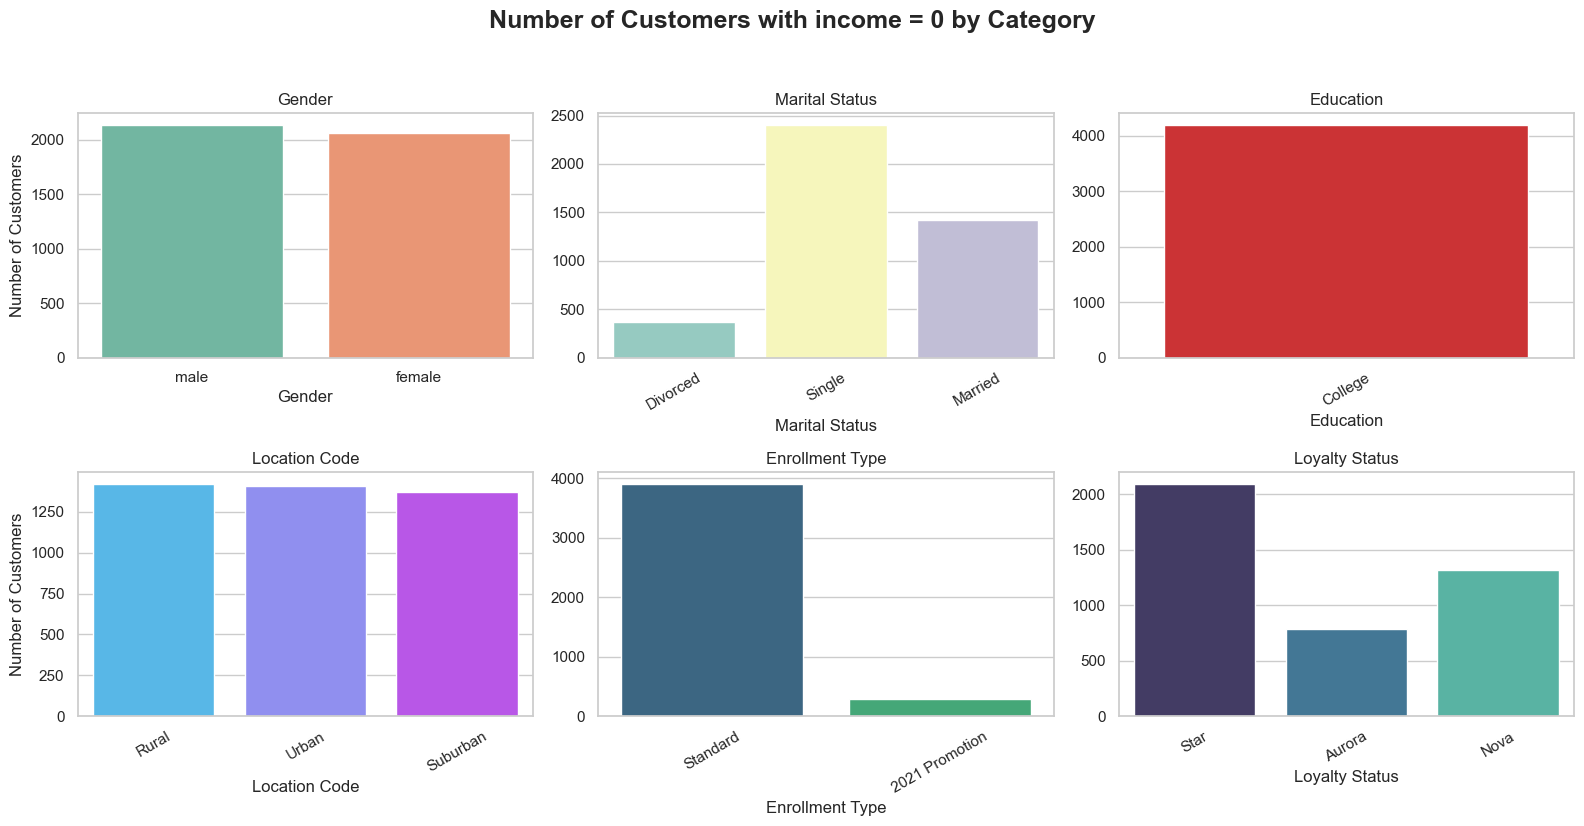

In [15]:
# Set style
sns.set(style="whitegrid")

# Create figure with 6 subplots (2 rows x 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# Number of customers by Gender
sns.countplot(data=zero_income, x="Gender", palette="Set2", ax=axes[0, 0])
axes[0, 0].set_title("Gender")
axes[0, 0].set_xlabel("Gender")
axes[0, 0].set_ylabel("Number of Customers")

# Number of customers by Marital Status
sns.countplot(data=zero_income, x="Marital Status", palette="Set3", ax=axes[0, 1])
axes[0, 1].set_title("Marital Status")
axes[0, 1].set_xlabel("Marital Status")
axes[0, 1].set_ylabel("")
axes[0, 1].tick_params(axis='x', rotation=30)

# Number of customers by Education
sns.countplot(data=zero_income, x="Education", palette="Set1", ax=axes[0, 2])
axes[0, 2].set_title("Education")
axes[0, 2].set_xlabel("Education")
axes[0, 2].set_ylabel("")
axes[0, 2].tick_params(axis='x', rotation=30)

# Number of customers by Location Code
sns.countplot(data=zero_income, x="Location Code", palette="cool", ax=axes[1, 0])
axes[1, 0].set_title("Location Code")
axes[1, 0].set_xlabel("Location Code")
axes[1, 0].set_ylabel("Number of Customers")
axes[1, 0].tick_params(axis='x', rotation=30)

# Number of customers by Enrollment Type
sns.countplot(data=zero_income, x="EnrollmentType", palette="viridis", ax=axes[1, 1])
axes[1, 1].set_title("Enrollment Type")
axes[1, 1].set_xlabel("Enrollment Type")
axes[1, 1].set_ylabel("")
axes[1, 1].tick_params(axis='x', rotation=30)

# Number of customers by Loyalty Status
sns.countplot(data=zero_income, x="LoyaltyStatus", palette="mako", ax=axes[1, 2])
axes[1, 2].set_title("Loyalty Status")
axes[1, 2].set_xlabel("Loyalty Status")
axes[1, 2].set_ylabel("")
axes[1, 2].tick_params(axis='x', rotation=30)

# Add general title
fig.suptitle("Number of Customers with income = 0 by Category", fontsize=18, fontweight='bold', y=1.03)

# Adjust layout
plt.tight_layout()
plt.show()

In [16]:
(dataset.loc[dataset["Education"] == "College", "Income"] == 0).all()

np.True_

For the analysis done above we can conclude that customer with income = 0:  
    - All have a education degree = College (the lowest one in our dataset). We can also see that all college customer have an income of 0  
    - The majority are Single  
    - Almost all have a Standard Enrollment Type

In [17]:
print("\n=== City ===")
print(zero_income["City"].value_counts())


=== City ===
City
Toronto           831
Vancouver         652
Montreal          538
Winnipeg          172
Whistler          160
Trenton           129
Ottawa            128
Edmonton          127
Halifax           116
Victoria          105
Regina            104
Kingston          103
Fredericton       100
Quebec City       100
Dawson Creek       98
Tremblant          89
Hull               88
West Vancouver     74
Sudbury            68
Thunder Bay        67
St. John's         65
Calgary            52
London             47
Moncton            46
Banff              44
Whitehorse         31
Peace River        23
Kelowna            22
Charlottetown      19
Name: count, dtype: int64


C:\Users\Duarte\AppData\Local\Temp\ipykernel_14280\99857658.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=city_counts, x="City", y="Count", palette="viridis")


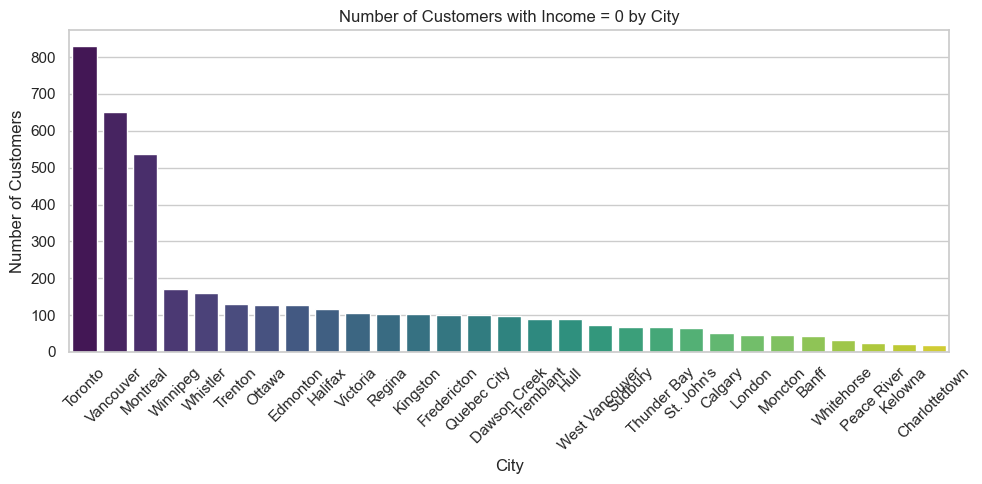

In [18]:
# Set style
sns.set(style="whitegrid")

# Calculate counts per city and sort descending
city_counts = zero_income["City"].value_counts().reset_index()
city_counts.columns = ["City", "Count"]

# Create figure
plt.figure(figsize=(10, 5))

# Bar chart: Number of customers by City
sns.barplot(data=city_counts, x="City", y="Count", palette="viridis")

plt.title("Number of Customers with Income = 0 by City")
plt.xlabel("City")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The distibution by City is completly align with the one where we consider all types of income. Nothing to add here.

In [19]:
print("\n=== IsActive ===")
print(zero_income["IsActive"].value_counts())


=== IsActive ===
IsActive
1    3623
0     575
Name: count, dtype: int64


The Majority of customer with income = 0 are still active

Regarding customers with income = 0, the data seems valid

## Non_Zero_Income Analysis

In [50]:
non_zero_income = dataset[dataset["Income"] != 0]
"""customer with income different from 0"""

'customer with income different from 0'

In [51]:
print("=== Gender ===")
print(non_zero_income["Gender"].value_counts())
print("\n=== Marital Status ===")
print(non_zero_income["Marital Status"].value_counts())
print("\n=== Education ===")
print(non_zero_income["Education"].value_counts())

=== Gender ===
Gender
female    6274
male      6102
Name: count, dtype: int64

=== Marital Status ===
Marital Status
Married     8221
Divorced    2117
Single      2038
Name: count, dtype: int64

=== Education ===
Education
Bachelor                10378
High School or Below      772
Doctor                    724
Master                    502
Name: count, dtype: int64


In [52]:
print("=== Location Code ===")
print(non_zero_income["Location Code"].value_counts())
print("\n=== EnrollmentType ===")
print(non_zero_income["EnrollmentType"].value_counts())
print("\n=== LoyaltyStatus ===")
print(non_zero_income["LoyaltyStatus"].value_counts())

=== Location Code ===
Location Code
Suburban    4238
Rural       4135
Urban       4003
Name: count, dtype: int64

=== EnrollmentType ===
EnrollmentType
Standard          11523
2021 Promotion      853
Name: count, dtype: int64

=== LoyaltyStatus ===
LoyaltyStatus
Star      5502
Nova      4292
Aurora    2582
Name: count, dtype: int64


C:\Users\Duarte\AppData\Local\Temp\ipykernel_14280\3732720629.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=non_zero_income, x="Gender", palette="Set2", ax=axes[0, 0])
C:\Users\Duarte\AppData\Local\Temp\ipykernel_14280\3732720629.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=non_zero_income, x="Marital Status", palette="Set3", ax=axes[0, 1])
C:\Users\Duarte\AppData\Local\Temp\ipykernel_14280\3732720629.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=non_zero_income, x="Education", palette="Set1", ax=axe

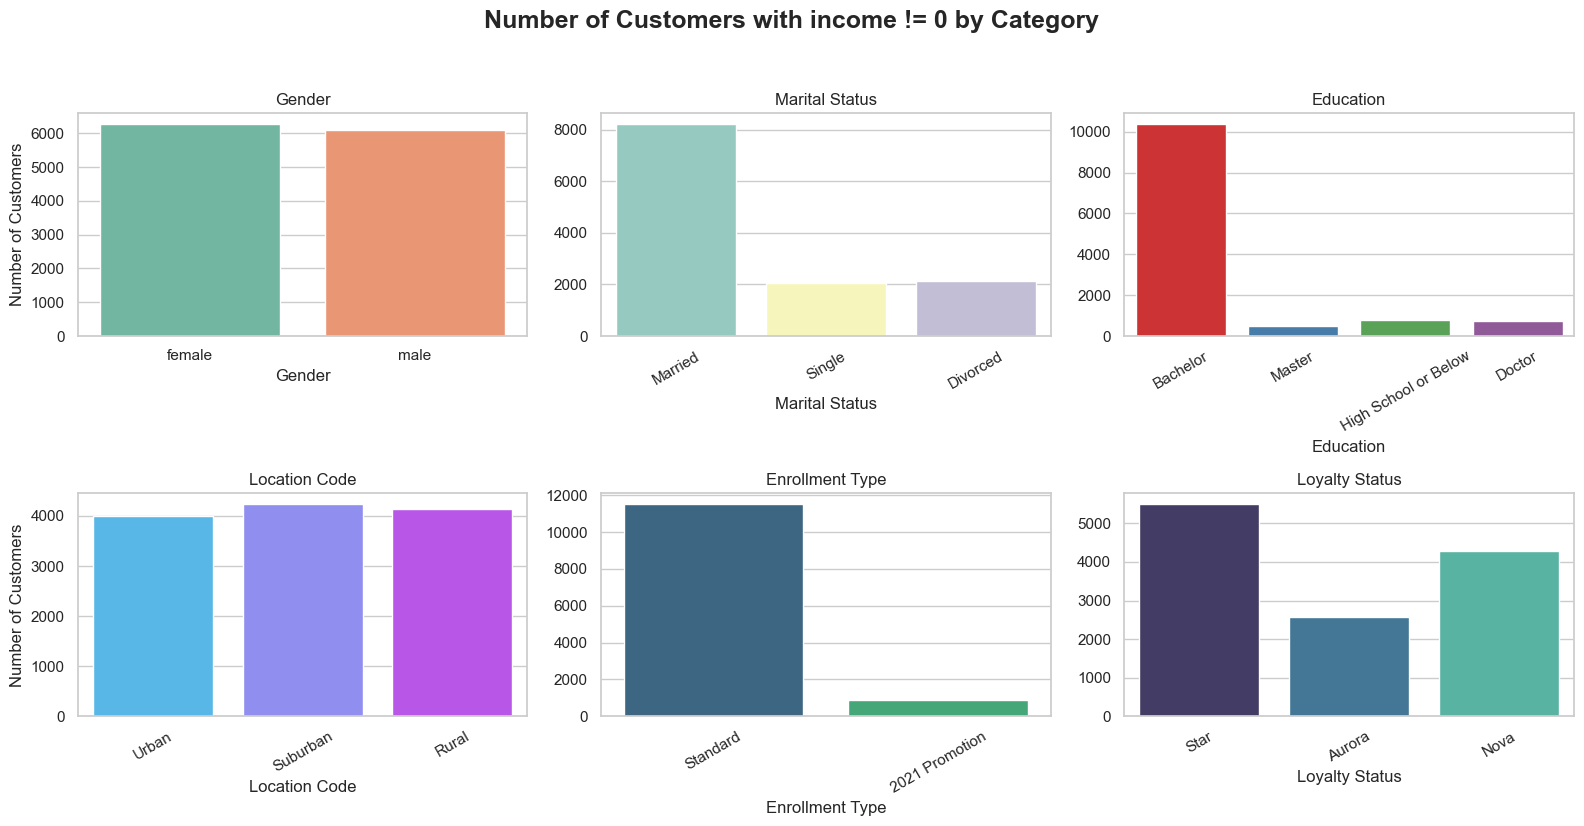

In [53]:
# Set style
sns.set(style="whitegrid")

# Create figure with 6 subplots (2 rows x 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# Number of customers by Gender
sns.countplot(data=non_zero_income, x="Gender", palette="Set2", ax=axes[0, 0])
axes[0, 0].set_title("Gender")
axes[0, 0].set_xlabel("Gender")
axes[0, 0].set_ylabel("Number of Customers")

# Number of customers by Marital Status
sns.countplot(data=non_zero_income, x="Marital Status", palette="Set3", ax=axes[0, 1])
axes[0, 1].set_title("Marital Status")
axes[0, 1].set_xlabel("Marital Status")
axes[0, 1].set_ylabel("")
axes[0, 1].tick_params(axis='x', rotation=30)

# Number of customers by Education
sns.countplot(data=non_zero_income, x="Education", palette="Set1", ax=axes[0, 2])
axes[0, 2].set_title("Education")
axes[0, 2].set_xlabel("Education")
axes[0, 2].set_ylabel("")
axes[0, 2].tick_params(axis='x', rotation=30)

# Number of customers by Location Code
sns.countplot(data=non_zero_income, x="Location Code", palette="cool", ax=axes[1, 0])
axes[1, 0].set_title("Location Code")
axes[1, 0].set_xlabel("Location Code")
axes[1, 0].set_ylabel("Number of Customers")
axes[1, 0].tick_params(axis='x', rotation=30)

# Number of customers by Enrollment Type
sns.countplot(data=non_zero_income, x="EnrollmentType", palette="viridis", ax=axes[1, 1])
axes[1, 1].set_title("Enrollment Type")
axes[1, 1].set_xlabel("Enrollment Type")
axes[1, 1].set_ylabel("")
axes[1, 1].tick_params(axis='x', rotation=30)

# Number of customers by Loyalty Status
sns.countplot(data=non_zero_income, x="LoyaltyStatus", palette="mako", ax=axes[1, 2])
axes[1, 2].set_title("Loyalty Status")
axes[1, 2].set_xlabel("Loyalty Status")
axes[1, 2].set_ylabel("")
axes[1, 2].tick_params(axis='x', rotation=30)

# Add general title
fig.suptitle("Number of Customers with income != 0 by Category", fontsize=18, fontweight='bold', y=1.03)

# Adjust layout
plt.tight_layout()
plt.show()

In [67]:
dataset.groupby('LoyaltyStatus')['Income'].mean()

LoyaltyStatus
Aurora    40101.387519
Nova      38946.834789
Star      35802.932614
Name: Income, dtype: float64

In [68]:
dataset.groupby('LoyaltyStatus')['Income'].median()

LoyaltyStatus
Aurora    38210.0
Nova      36094.0
Star      30817.0
Name: Income, dtype: float64

In [69]:
dataset.groupby('LoyaltyStatus')['Income'].agg(['min', 'max'])

,min,max
LoyaltyStatus,,
Aurora,0.0,99960.0
Nova,0.0,99981.0
Star,0.0,99961.0


For the remaining Income Analysis we will only consider income > 0

### Levels of Income by Gender

In [78]:
dataset.groupby('Gender')['Income'].mean()

Gender
female    38033.716977
male      37442.834082
Name: Income, dtype: float64

In [79]:
dataset.groupby('Gender')['Income'].median()

Gender
female    34161.0
male      34112.0
Name: Income, dtype: float64

In [80]:
dataset.groupby('Gender')['Income'].agg(['min', 'max'])

,min,max
Gender,,
female,0.0,99981.0
male,0.0,99981.0


C:\Users\Duarte\AppData\Local\Temp\ipykernel_14280\1405924094.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=non_zero_income, x="Gender", y="Income", palette="Set2")


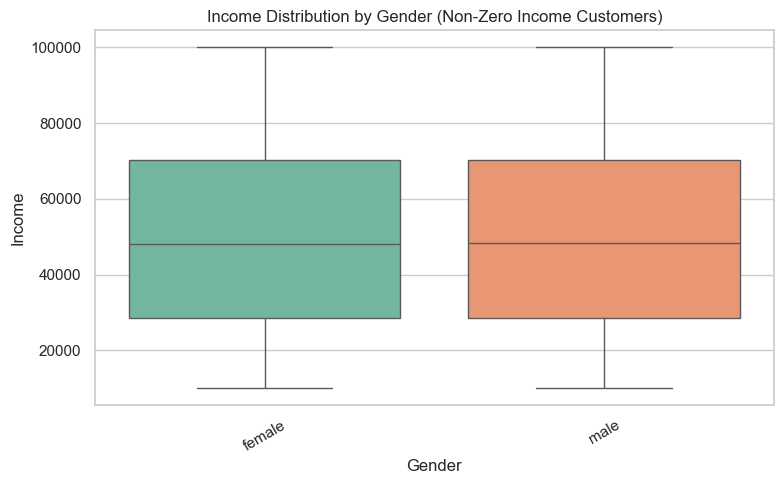

In [77]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=non_zero_income, x="Gender", y="Income", palette="Set2")

plt.title("Income Distribution by Gender (Non-Zero Income Customers)")
plt.xlabel("Gender")
plt.ylabel("Income")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Nothing to add here. Income well distributed between gender.

### Levels of Income by Education

In [54]:
dataset.groupby('Education')['Income'].mean()

Education
Bachelor                56359.408942
College                     0.000000
Doctor                  20070.616022
High School or Below    20335.269430
Master                  20666.615538
Name: Income, dtype: float64

In [70]:
dataset.groupby('Education')['Income'].median()

Education
Bachelor                55579.5
College                     0.0
Doctor                  20179.5
High School or Below    20480.5
Master                  21073.0
Name: Income, dtype: float64

In [55]:
dataset.groupby('Education')['Income'].agg(['min', 'max'])

,min,max
Education,,
Bachelor,20009.0,99981.0
College,0.0,0.0
Doctor,10097.0,29981.0
High School or Below,10037.0,29957.0
Master,10180.0,29692.0


C:\Users\Duarte\AppData\Local\Temp\ipykernel_14280\2730096441.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=non_zero_income, x="Education", y="Income", palette="Set2")


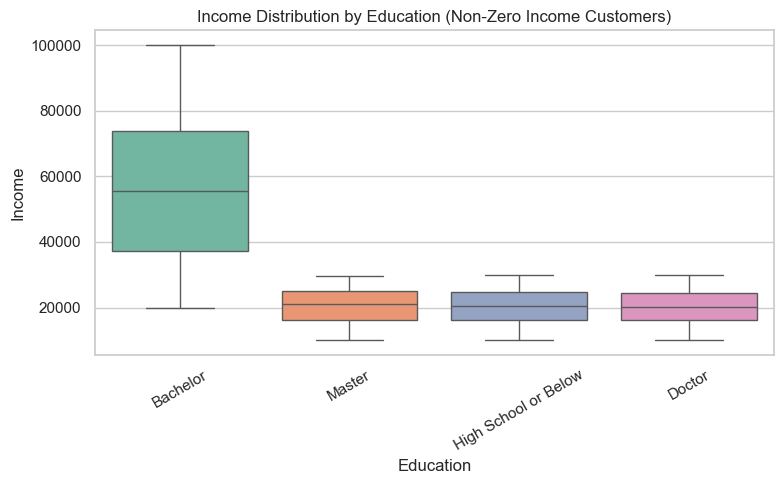

In [21]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=non_zero_income, x="Education", y="Income", palette="Set2")

plt.title("Income Distribution by Education (Non-Zero Income Customers)")
plt.xlabel("Education")
plt.ylabel("Income")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Its weird that the Income of Masters and Doctor is not bigger than the bachelor one. We can have here some outliers on the bachelor poll. To be checked

### Levels of Income by Marital Status

In [57]:
dataset.groupby('Marital Status')['Income'].mean()

Marital Status
Divorced    40781.406514
Married     43828.457599
Single      22812.402837
Name: Income, dtype: float64

In [71]:
dataset.groupby('Marital Status')['Income'].median()

Marital Status
Divorced    36791.0
Married     41459.0
Single          0.0
Name: Income, dtype: float64

In [58]:
dataset.groupby('Marital Status')['Income'].agg(['min', 'max'])

,min,max
Marital Status,,
Divorced,0.0,99875.0
Married,0.0,99981.0
Single,0.0,99816.0


C:\Users\Duarte\AppData\Local\Temp\ipykernel_14280\673810015.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=non_zero_income, x="Marital Status", y="Income", palette="Set2")


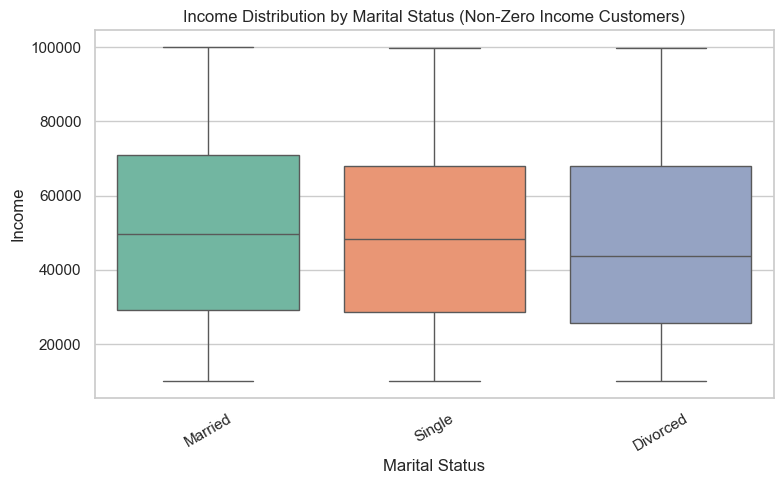

In [22]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=non_zero_income, x="Marital Status", y="Income", palette="Set2")

plt.title("Income Distribution by Marital Status (Non-Zero Income Customers)")
plt.xlabel("Marital Status")
plt.ylabel("Income")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Nothing to add here. Income well distributed between martital status.

### Levels of Income by Location Code

In [73]:
dataset.groupby('Location Code')['Income'].mean()

Location Code
Rural       37674.255174
Suburban    37975.735200
Urban       37563.095212
Name: Income, dtype: float64

In [72]:
dataset.groupby('Location Code')['Income'].median()

Location Code
Rural       33837.0
Suburban    34537.0
Urban       33992.0
Name: Income, dtype: float64

In [74]:
dataset.groupby('Location Code')['Income'].agg(['min', 'max'])

,min,max
Location Code,,
Rural,0.0,99981.0
Suburban,0.0,99981.0
Urban,0.0,99960.0


C:\Users\Duarte\AppData\Local\Temp\ipykernel_14280\1545480284.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=non_zero_income, x="Location Code", y="Income", palette="Set2")


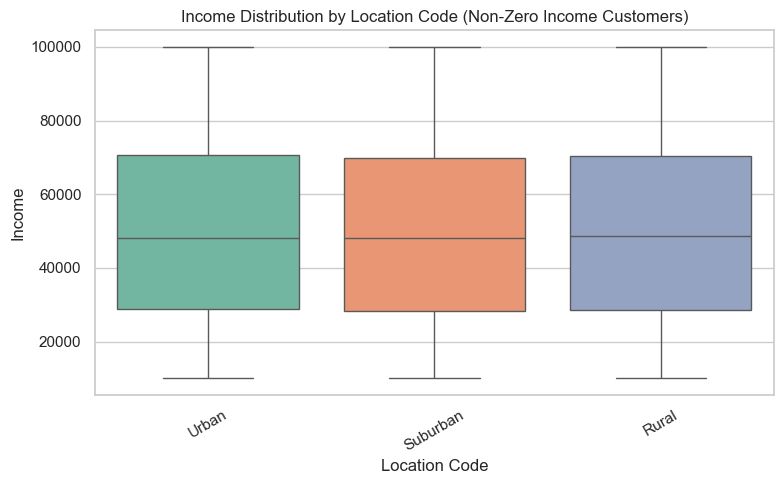

In [75]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=non_zero_income, x="Location Code", y="Income", palette="Set2")

plt.title("Income Distribution by Location Code (Non-Zero Income Customers)")
plt.xlabel("Location Code")
plt.ylabel("Income")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Levels of Income by Enrollment Type

In [81]:
dataset.groupby('EnrollmentType')['Income'].mean()

EnrollmentType
2021 Promotion    37802.535149
Standard          37735.375486
Name: Income, dtype: float64

In [82]:
dataset.groupby('EnrollmentType')['Income'].median()

EnrollmentType
2021 Promotion    34990.0
Standard          34103.5
Name: Income, dtype: float64

In [83]:
dataset.groupby('EnrollmentType')['Income'].agg(['min', 'max'])

,min,max
EnrollmentType,,
2021 Promotion,0.0,99960.0
Standard,0.0,99981.0


C:\Users\Duarte\AppData\Local\Temp\ipykernel_14280\997499650.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=non_zero_income, x="EnrollmentType", y="Income", palette="Set2")


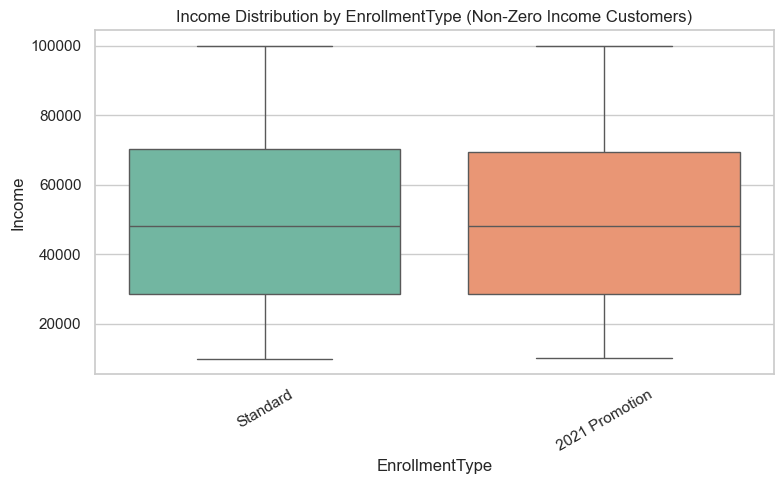

In [84]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=non_zero_income, x="EnrollmentType", y="Income", palette="Set2")

plt.title("Income Distribution by EnrollmentType (Non-Zero Income Customers)")
plt.xlabel("EnrollmentType")
plt.ylabel("Income")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Levels of Income by Loyalty Status

In [87]:
dataset.groupby('LoyaltyStatus')['Income'].mean()

LoyaltyStatus
Aurora    40101.387519
Nova      38946.834789
Star      35802.932614
Name: Income, dtype: float64

In [88]:
dataset.groupby('LoyaltyStatus')['Income'].median()

LoyaltyStatus
Aurora    38210.0
Nova      36094.0
Star      30817.0
Name: Income, dtype: float64

In [89]:
dataset.groupby('LoyaltyStatus')['Income'].agg(['min', 'max'])

,min,max
LoyaltyStatus,,
Aurora,0.0,99960.0
Nova,0.0,99981.0
Star,0.0,99961.0


C:\Users\Duarte\AppData\Local\Temp\ipykernel_14280\742682327.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=non_zero_income, x="LoyaltyStatus", y="Income", palette="Set2")


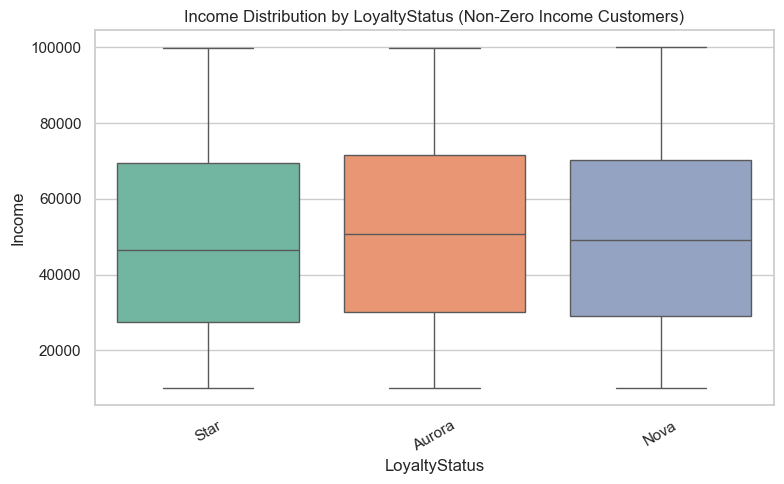

In [24]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=non_zero_income, x="LoyaltyStatus", y="Income", palette="Set2")

plt.title("Income Distribution by LoyaltyStatus (Non-Zero Income Customers)")
plt.xlabel("LoyaltyStatus")
plt.ylabel("Income")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Nothing to add here. Income well distributed between Loyalty Status.

### Levels of Income by CustomerLifetimeValue

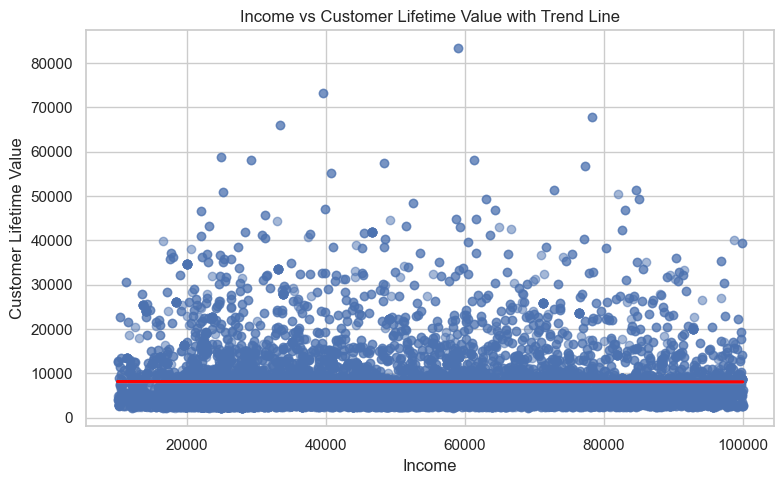

In [25]:
plt.figure(figsize=(8, 5))
sns.regplot(data=non_zero_income, x="Income", y="Customer Lifetime Value", scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.title("Income vs Customer Lifetime Value with Trend Line")
plt.xlabel("Income")
plt.ylabel("Customer Lifetime Value")
plt.tight_layout()
plt.show()

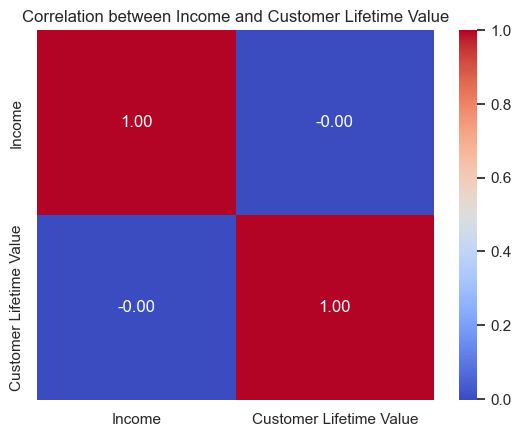

In [26]:
corr = non_zero_income[["Income", "Customer Lifetime Value"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation between Income and Customer Lifetime Value")
plt.show()

There is no correlation between income and CustomerLifeTimeValue

# Gender Analysis

## Gender by number of customers

C:\Users\Duarte\AppData\Local\Temp\ipykernel_14280\831069441.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dataset, x="Gender", palette="pastel", order=dataset["Gender"].value_counts().index)


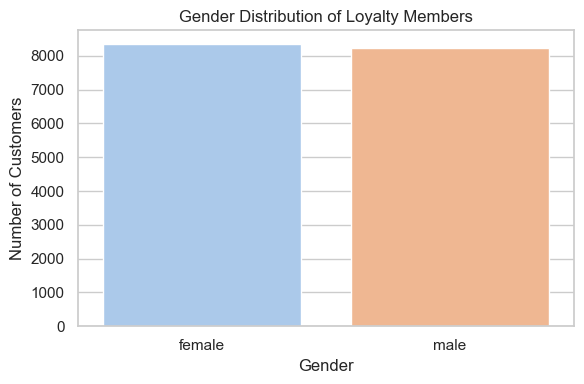


Gender distribution (%):
Gender
female    50.3
male      49.7
Name: proportion, dtype: float64


In [27]:
plt.figure(figsize=(6,4))
sns.countplot(data=dataset, x="Gender", palette="pastel", order=dataset["Gender"].value_counts().index)
plt.title("Gender Distribution of Loyalty Members")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

print("\nGender distribution (%):")
print((dataset["Gender"].value_counts(normalize=True) * 100).round(1))

## Gender by Education

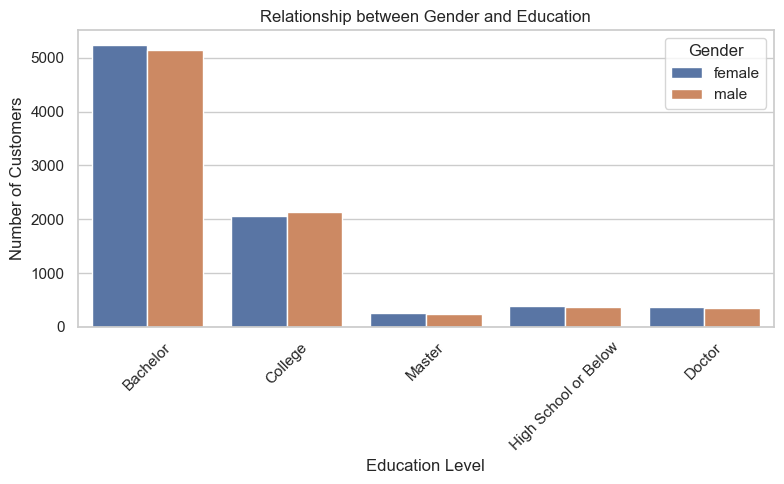

In [28]:
# Assuming your DataFrame is named 'dataset'
plt.figure(figsize=(8, 5))

# Countplot to show the distribution
sns.countplot(data=dataset, x='Education', hue='Gender')

plt.title('Relationship between Gender and Education')
plt.xlabel('Education Level')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

## Gender by Loyalty Status

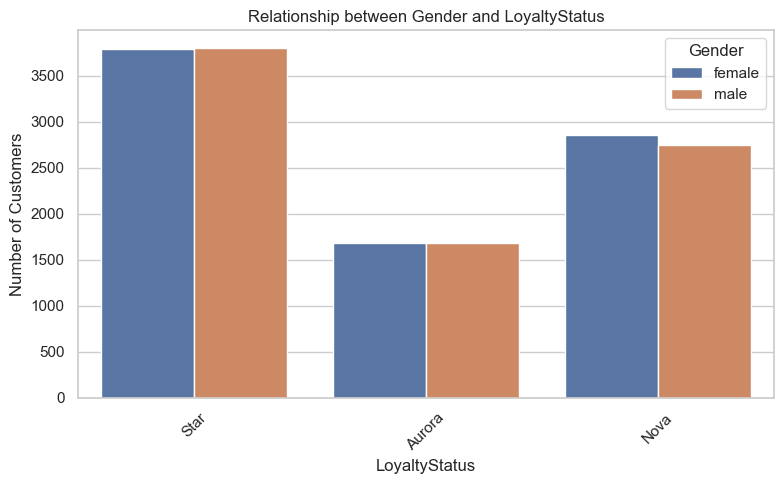

In [29]:
# Assuming your DataFrame is named 'dataset'
plt.figure(figsize=(8, 5))

# Countplot to show the distribution
sns.countplot(data=dataset, x='LoyaltyStatus', hue='Gender')

plt.title('Relationship between Gender and LoyaltyStatus')
plt.xlabel('LoyaltyStatus')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

## Gender by CustomerLifeTimeValue

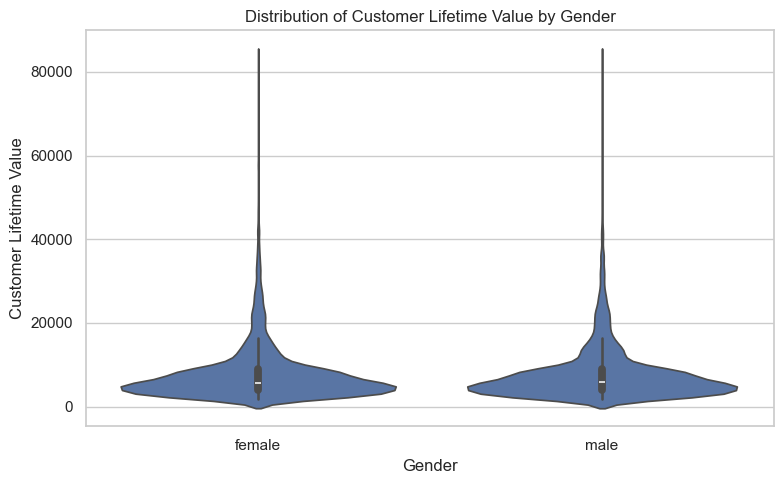

In [30]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=dataset, x='Gender', y='Customer Lifetime Value', inner='box')
plt.title('Distribution of Customer Lifetime Value by Gender')
plt.xlabel('Gender')
plt.ylabel('Customer Lifetime Value')
plt.tight_layout()
plt.show()

## Gender by City

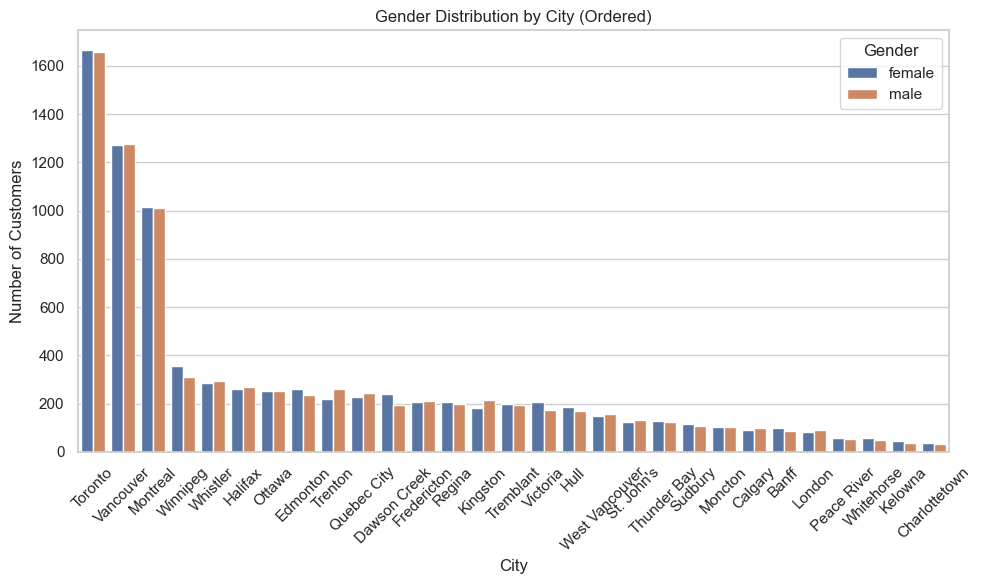

In [91]:
# Order cities by total number of customers
city_order = (
    dataset['City']
    .value_counts()
    .index
)

plt.figure(figsize=(10, 6))
sns.countplot(
    data=dataset,
    x='City',
    hue='Gender',
    order=city_order
)
plt.title('Gender Distribution by City (Ordered)')
plt.xlabel('City')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Education Analysis

C:\Users\Duarte\AppData\Local\Temp\ipykernel_14280\1555673567.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dataset, x="Education", order=order, palette="muted")


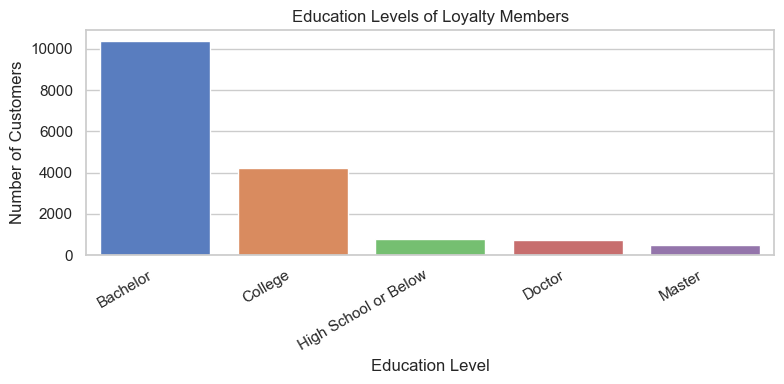


Education distribution (%):
Education
Bachelor                62.6
College                 25.3
High School or Below     4.7
Doctor                   4.4
Master                   3.0
Name: proportion, dtype: float64


In [31]:
# Education distibution

plt.figure(figsize=(8,4))
order = dataset["Education"].value_counts().index  # sort by most frequent
sns.countplot(data=dataset, x="Education", order=order, palette="muted")
plt.title("Education Levels of Loyalty Members")
plt.xlabel("Education Level")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print("\nEducation distribution (%):")
print((dataset["Education"].value_counts(normalize=True) * 100).round(1))

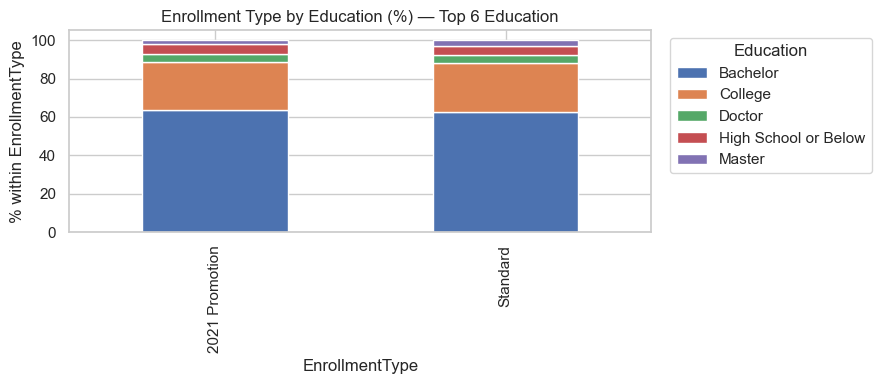

In [113]:
# EnrollmentType by Education

if set(["EnrollmentType","Education"]).issubset(dataset.columns):
    # limit to top education categories to avoid clutter
    top_edu = dataset["Education"].value_counts().nlargest(6).index
    sub = dataset[dataset["Education"].isin(top_edu)].copy()
    ctab = pd.crosstab(sub["EnrollmentType"], sub["Education"], normalize="index") * 100
    ax = ctab.plot(kind="bar", stacked=True, figsize=(9,4))
    plt.title("Enrollment Type by Education (%) — Top 6 Education")
    plt.ylabel("% within EnrollmentType")
    plt.xlabel("EnrollmentType")
    plt.legend(title="Education", bbox_to_anchor=(1.02,1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("EnrollmentType and/or Education columns not found.")

# Martial Status Analysis

C:\Users\Duarte\AppData\Local\Temp\ipykernel_14280\985453244.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dataset, x="Marital Status", palette="pastel", order=dataset["Marital Status"].value_counts().index)


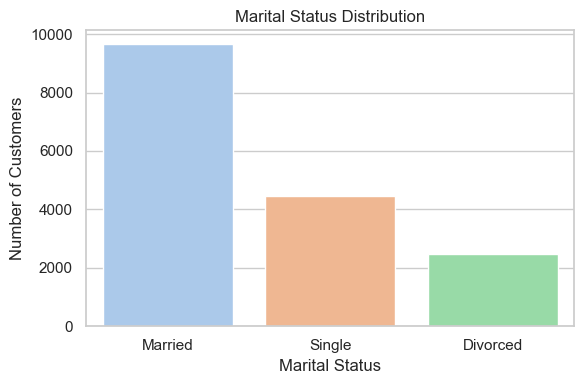


Marital Status (%):
Marital Status
Married     58.2
Single      26.8
Divorced    15.0
Name: proportion, dtype: float64


In [32]:
# Marital Status

plt.figure(figsize=(6,4))
sns.countplot(data=dataset, x="Marital Status", palette="pastel", order=dataset["Marital Status"].value_counts().index)
plt.title("Marital Status Distribution")
plt.xlabel("Marital Status")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

print("\nMarital Status (%):")
print((dataset["Marital Status"].value_counts(normalize=True) * 100).round(1))

# Demographic Analysis

## Customer Distribution by City and Province by city

In [104]:
province_counts = (
    dataset['Province or State']
    .value_counts(dropna=False)
    .rename_axis('Province')
    .reset_index(name='CustomerCount')
)
print("Top Provinces by Customer Count:\n")
print(province_counts)

Top Provinces by Customer Count:

                Province  CustomerCount
0                Ontario           5354
1       British Columbia           4333
2                 Quebec           3245
3                Alberta            987
4               Manitoba            666
5          New Brunswick            629
6            Nova Scotia            529
7           Saskatchewan            404
8           Newfoundland            253
9                  Yukon            108
10  Prince Edward Island             66


In [103]:
city_counts = (
    dataset['City']
    .value_counts(dropna=False)
    .rename_axis('City')
    .reset_index(name='CustomerCount')
)
print("Top Cities by Customer Count:\n")
print(city_counts)

Top Cities by Customer Count:

              City  CustomerCount
0          Toronto           3323
1        Vancouver           2551
2         Montreal           2028
3         Winnipeg            666
4         Whistler            579
5          Halifax            529
6           Ottawa            505
7         Edmonton            496
8          Trenton            482
9      Quebec City            472
10    Dawson Creek            434
11     Fredericton            419
12          Regina            404
13        Kingston            397
14       Tremblant            390
15        Victoria            382
16            Hull            355
17  West Vancouver            308
18      St. John's            253
19     Thunder Bay            251
20         Sudbury            224
21         Moncton            210
22         Calgary            192
23           Banff            186
24          London            172
25     Peace River            113
26      Whitehorse            108
27         Kelown

In [105]:
province_city_counts = (
    dataset.groupby(['Province or State', 'City'])
    .size()
    .reset_index(name='CustomerCount')
    .sort_values('CustomerCount', ascending=False)
    .reset_index(drop=True)
)
print("Top Province + City combinations by Customer Count:\n")
print(province_city_counts)

Top Province + City combinations by Customer Count:

       Province or State            City  CustomerCount
0                Ontario         Toronto           3323
1       British Columbia       Vancouver           2551
2                 Quebec        Montreal           2028
3               Manitoba        Winnipeg            666
4       British Columbia        Whistler            579
5            Nova Scotia         Halifax            529
6                Ontario          Ottawa            505
7                Alberta        Edmonton            496
8                Ontario         Trenton            482
9                 Quebec     Quebec City            472
10      British Columbia    Dawson Creek            434
11         New Brunswick     Fredericton            419
12          Saskatchewan          Regina            404
13               Ontario        Kingston            397
14                Quebec       Tremblant            390
15      British Columbia        Victoria           

In [110]:
# === Tunables ===
TOP_N_PER_PROVINCE = 8      # set None to keep all cities
ADD_OTHER_BUCKET = True     # put smaller cities into "Other" per province

# --- Prep counts ---
counts = (
    dataset.groupby(['Province or State','City'])
    .size()
    .reset_index(name='CustomerCount')
)

# Handle missing labels cleanly
counts['Province or State'] = counts['Province or State'].fillna('Unknown Province')
counts['City'] = counts['City'].fillna('Unknown City')

# Province totals and shares
prov_totals = counts.groupby('Province or State')['CustomerCount'].transform('sum')
total = counts['CustomerCount'].sum()
counts['ShareInProvince'] = counts['CustomerCount'] / prov_totals
counts['ShareTotal'] = counts['CustomerCount'] / total

# Keep top-N cities per province (optional), bucket others as "Other"
if TOP_N_PER_PROVINCE is not None and ADD_OTHER_BUCKET:
    counts = counts.sort_values(['Province or State','CustomerCount'], ascending=[True, False])
    counts['RankInProvince'] = counts.groupby('Province or State')['CustomerCount'].rank(method='first', ascending=False)
    top = counts[counts['RankInProvince'] <= TOP_N_PER_PROVINCE].copy()
    other = counts[counts['RankInProvince'] > TOP_N_PER_PROVINCE].copy()

    if not other.empty:
        other_sum = (
            other.groupby('Province or State', as_index=False)
                 .agg({'CustomerCount':'sum'})
                 .rename(columns={'CustomerCount':'CustomerCount'})
        )
        other_sum['City'] = 'Other'
        # recompute shares for "Other"
        prov_total_map = top.groupby('Province or State')['CustomerCount'].sum().add(
            other_sum.set_index('Province or State')['CustomerCount'], fill_value=0
        )
        other_sum['ShareInProvince'] = other_sum.apply(
            lambda r: r['CustomerCount'] / prov_total_map[r['Province or State']], axis=1
        )
        other_sum['ShareTotal'] = other_sum['CustomerCount'] / total

        counts = pd.concat([top[['Province or State','City','CustomerCount','ShareInProvince','ShareTotal']], 
                            other_sum[['Province or State','City','CustomerCount','ShareInProvince','ShareTotal']]], 
                           ignore_index=True)

# Sort for nicer legend order
counts = counts.sort_values(['CustomerCount'], ascending=False)

# Treemap
fig = px.treemap(
    counts,
    path=['Province or State', 'City'],
    values='CustomerCount',
    color='Province or State',                 # color by province for clear grouping
    title='Cities within Provinces (Treemap, sized by customer count)',
)

# Better labels + hover
fig.update_traces(
    hovertemplate=(
        "<b>%{label}</b><br>"
        "Province: %{parent}<br>"
        "Customers: %{value:,}<br>"
        "Share of province: %{customdata[0]:.1%}<br>"
        "Share of total: %{customdata[1]:.1%}<extra></extra>"
    ),
    customdata=counts[['ShareInProvince','ShareTotal']],
    texttemplate="%{label}<br>%{value:,}",
    textfont_size=12,
    marker=dict(line=dict(width=1))
)

# Layout polish
fig.update_layout(
    height=700,
    margin=dict(l=20, r=20, t=60, b=20),
    uniformtext=dict(minsize=10, mode='show')
)

fig.show()


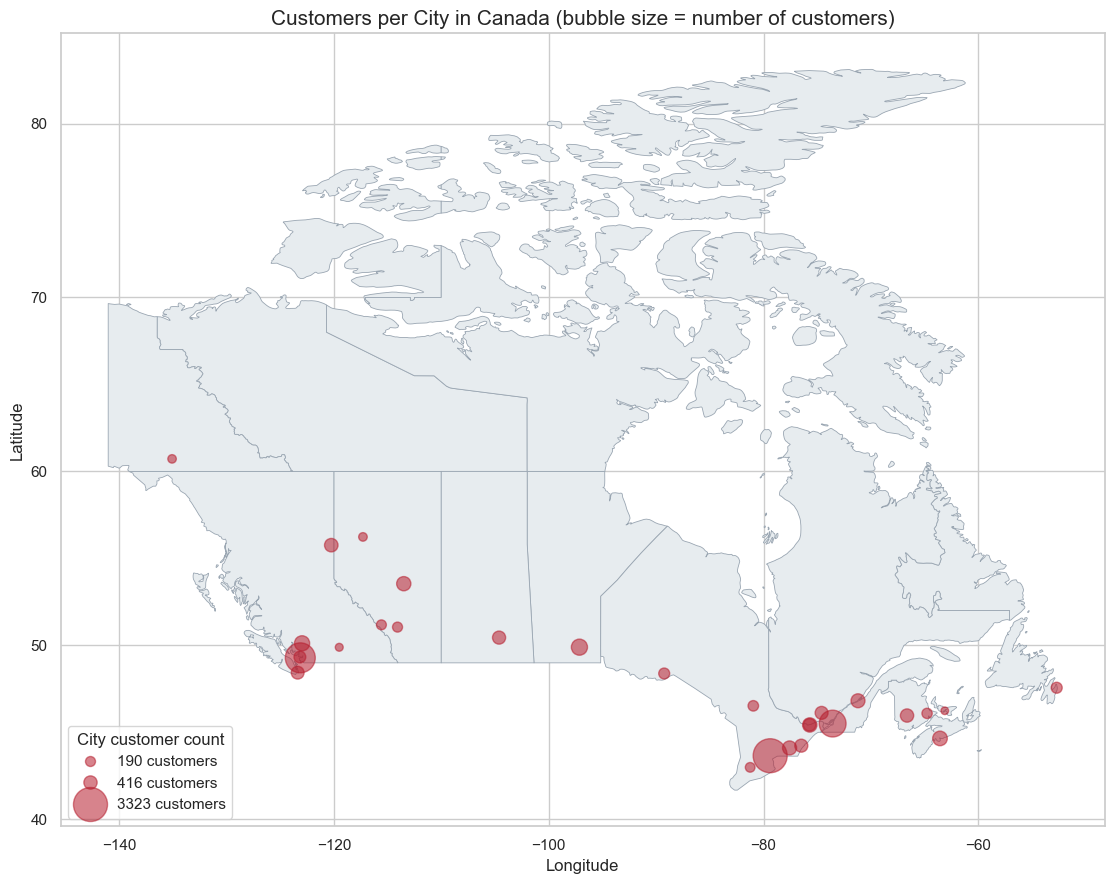

In [111]:
# 1) Prepare data
df = dataset.copy()
df["Latitude"]  = pd.to_numeric(df["Latitude"],  errors="coerce")
df["Longitude"] = pd.to_numeric(df["Longitude"], errors="coerce")
df = df.dropna(subset=["Latitude", "Longitude"]).reset_index(drop=True)

# Aggregate customers per city
city_agg = (
    df.groupby(["Province or State", "City"])
      .agg(CustomerCount=("City", "size"),
           Latitude=("Latitude", "mean"),
           Longitude=("Longitude", "mean"))
      .reset_index()
)

# 2) Canada provinces layer
admin1_url = "https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_1_states_provinces.zip"
admin1 = gpd.read_file(admin1_url).to_crs("EPSG:4326")
canada_admin1 = admin1.loc[admin1["admin"] == "Canada", ["name", "geometry"]].copy()

# 3) GeoDataFrame for city bubbles
cities_gdf = gpd.GeoDataFrame(
    city_agg,
    geometry=gpd.points_from_xy(city_agg["Longitude"], city_agg["Latitude"]),
    crs="EPSG:4326"
)

# 4) Size scaling (scatter 's' is area in points^2)
counts = cities_gdf["CustomerCount"].astype(float).values
size_min, size_max = 30, 600  # adjust if needed
if counts.size > 0:
    cmin, cmax = counts.min(), counts.max()
    if cmin == cmax:
        sizes = np.full_like(counts, (size_min + size_max) / 2.0)
    else:
        sizes = np.interp(counts, (cmin, cmax), (size_min, size_max))
else:
    sizes = np.array([])

# 5) Plot
fig, ax = plt.subplots(figsize=(12, 9))
canada_admin1.plot(ax=ax, color="#E7ECEF", edgecolor="#9AA6B2", linewidth=0.6)

cities_gdf.plot(
    ax=ax,
    markersize=sizes,            # bubble sizes (area)
    color="#B61E2E",
    alpha=0.55
)

ax.set_title("Customers per City in Canada (bubble size = number of customers)", fontsize=15)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")

# --- Custom bubble legend (robust across Matplotlib versions) ---
if counts.size > 0:
    # Choose representative counts (min, median, max or 3 quantiles)
    reps = np.unique(np.ceil(np.quantile(counts, [0.2, 0.6, 1.0])).astype(int))
    # Map those counts to scatter areas and then to Line2D marker sizes (radius ~ sqrt(area))
    rep_sizes = []
    for r in reps:
        if cmin == cmax:
            s = (size_min + size_max) / 2.0
        else:
            s = np.interp(r, (cmin, cmax), (size_min, size_max))
        rep_sizes.append(s)

    handles = [
        Line2D([0], [0],
               marker='o', linestyle='',
               markersize=np.sqrt(s),   # convert area to marker size
               markerfacecolor="#B61E2E", markeredgecolor="#B61E2E", alpha=0.55)
        for s in rep_sizes
    ]
    labels = [f"{int(r)} customers" for r in reps]
    ax.legend(handles, labels, title="City customer count", frameon=True, loc="lower left")

plt.tight_layout(); plt.show()



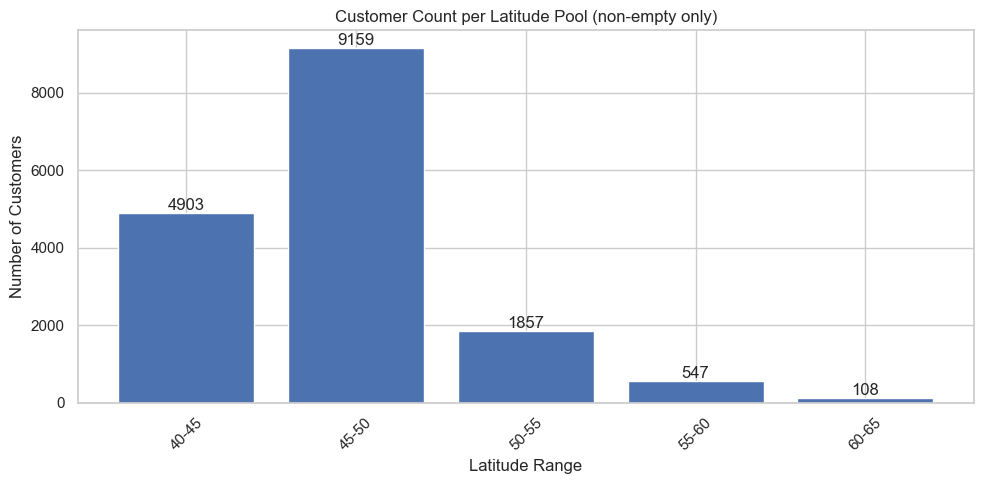

In [119]:
# --- bins e contagem ---
lat_bins = range(40, 91, 5)
lat_labels = [f"{b}-{b+5}" for b in lat_bins[:-1]]

lat_pool = pd.cut(
    dataset['Latitude'],
    bins=lat_bins,
    labels=lat_labels,
    include_lowest=True
)
lat_counts = (
    lat_pool.value_counts()
    .rename_axis('LatitudePool')
    .reset_index(name='CustomerCount')
    .sort_values('LatitudePool')  # ordem natural dos bins
)

# manter só pools com > 0
lat_counts = lat_counts[lat_counts['CustomerCount'] > 0].reset_index(drop=True)

# --- gráfico ---
plt.figure(figsize=(10, 5))
plt.bar(lat_counts['LatitudePool'], lat_counts['CustomerCount'])
plt.title('Customer Count per Latitude Pool (non-empty only)')
plt.xlabel('Latitude Range')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)

# rótulos em cima de cada barra
for i, v in enumerate(lat_counts['CustomerCount']):
    plt.text(i, v + 0.5, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

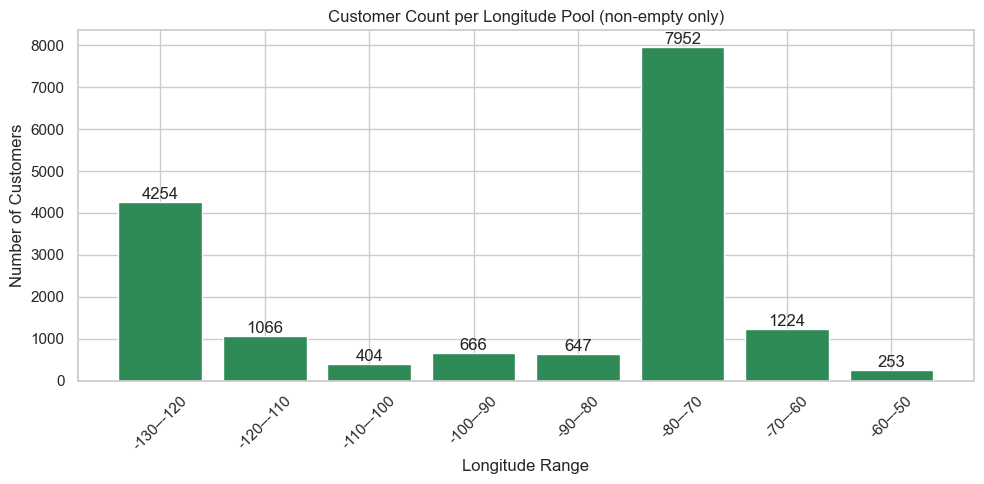

In [123]:
# --- bins e labels ---
lon_bins = range(-130, -49, 10)
lon_labels = [f"{b}–{b+10}" for b in lon_bins[:-1]]

# criar pools
lon_pool = pd.cut(
    dataset['Longitude'],
    bins=lon_bins,
    labels=lon_labels,
    include_lowest=True
)

# contagem por pool
lon_counts = (
    lon_pool.value_counts()
    .rename_axis('LongitudePool')
    .reset_index(name='CustomerCount')
    .sort_values('LongitudePool')  # ordenar pelos intervalos
)

# manter só os pools com casos (>0)
lon_counts = lon_counts[lon_counts['CustomerCount'] > 0].reset_index(drop=True)

# --- gráfico ---
plt.figure(figsize=(10, 5))
plt.bar(lon_counts['LongitudePool'], lon_counts['CustomerCount'], color='seagreen')
plt.title('Customer Count per Longitude Pool (non-empty only)')
plt.xlabel('Longitude Range')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)

# rótulos com valores em cima das barras
for i, v in enumerate(lon_counts['CustomerCount']):
    plt.text(i, v + 0.5, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [125]:
# --- Define bins and labels ---
lat_bins = range(40, 91, 5)          # 40–90 step 5
lon_bins = range(-130, -49, 10)      # -130–-50 step 10
lat_labels = [f"{b}–{b+5}" for b in lat_bins[:-1]]
lon_labels = [f"{b}–{b+10}" for b in lon_bins[:-1]]

# Pools
dataset['LatPool'] = pd.cut(dataset['Latitude'], bins=lat_bins, labels=lat_labels, include_lowest=True)
dataset['LonPool'] = pd.cut(dataset['Longitude'], bins=lon_bins, labels=lon_labels, include_lowest=True)

# Count customers per city within each pool
# If you have CustomerID and want unique customers, replace .size() with .nunique()
city_counts = (
    dataset.groupby(['LatPool', 'LonPool', 'City'])
    .size()
    .reset_index(name='CustomerCount')
)

# Remove cities without pool (outside bounds)
city_counts = city_counts.dropna(subset=['LatPool','LonPool','City'])

fig = px.treemap(
    city_counts,
    path=['LatPool', 'LonPool', 'City'],     # hierarchy: Lat → Lon → City
    values='CustomerCount',
    title='Cities within Latitude/Longitude Pools (sized by customer count)'
)

# Nicer hover info
fig.update_traces(
    hovertemplate="<b>%{label}</b><br>Path: %{currentPath}<br>Customers: %{value:,}<extra></extra>"
)

fig.update_layout(margin=dict(l=20, r=20, t=60, b=20), height=750)
fig.show()

C:\Users\Duarte\AppData\Local\Temp\ipykernel_14280\1103361236.py:14: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

c:\Users\Duarte\anaconda3\Lib\site-packages\plotly\express\_core.py:1727: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

c:\Users\Duarte\anaconda3\Lib\site-packages\plotly\express\_core.py:1727: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

c:\Users\Duarte\anaconda3\Lib\site-packages\plotly\express\_core.py:1

## Province vs Gender

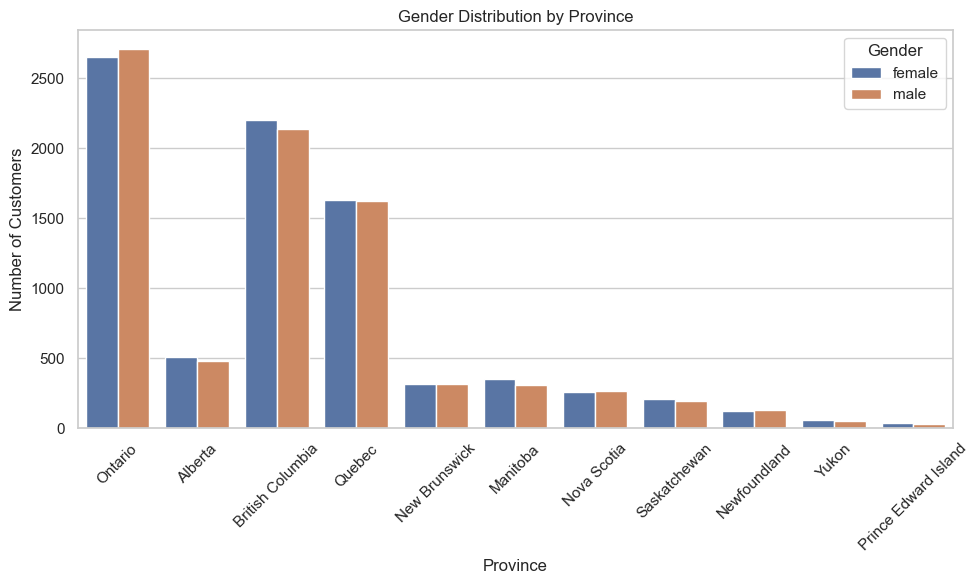

In [126]:
plt.figure(figsize=(10,6))
sns.countplot(data=dataset, x='Province or State', hue='Gender')
plt.title('Gender Distribution by Province')
plt.xlabel('Province')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Province vs Education

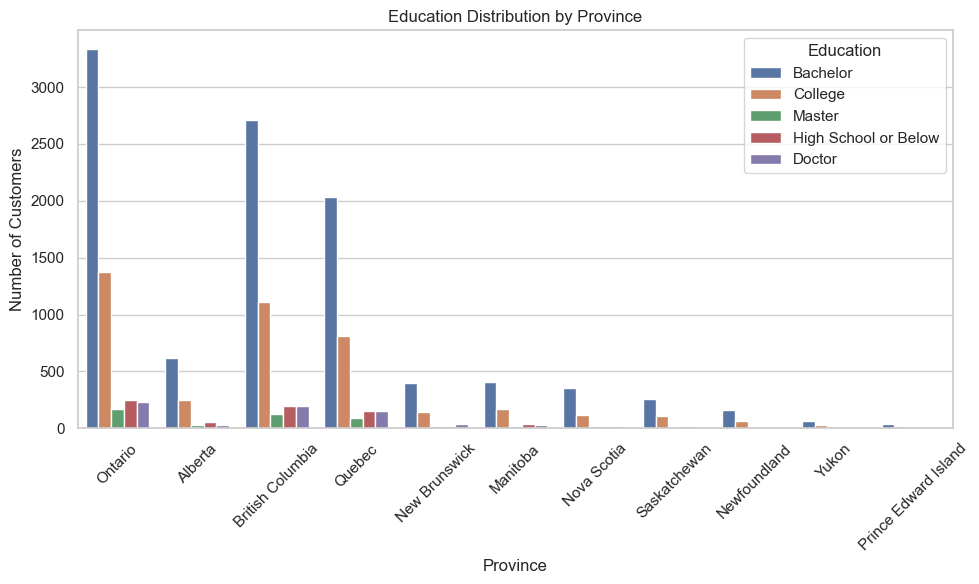

In [127]:
plt.figure(figsize=(10,6))
sns.countplot(data=dataset, x='Province or State', hue='Education')
plt.title('Education Distribution by Province')
plt.xlabel('Province')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Province vs Income (sum of total income by customers)

In [128]:
income_sum = (
    dataset.groupby('Province or State')['Income']
    .sum()
    .reset_index(name='TotalIncome')
    .sort_values('TotalIncome', ascending=False)
)

fig = px.bar(
    income_sum,
    x='Province or State',
    y='TotalIncome',
    title='Total Income by Province (Sum)',
    text_auto='.2s',
    color='TotalIncome',
    color_continuous_scale='Blues'
)
fig.update_layout(xaxis_title='Province', yaxis_title='Total Income', height=500)
fig.show()

## Province vs Income (Mean per customer)

In [129]:
income_mean = (
    dataset.groupby('Province or State')['Income']
    .mean()
    .reset_index(name='AverageIncome')
    .sort_values('AverageIncome', ascending=False)
)

fig = px.bar(
    income_mean,
    x='Province or State',
    y='AverageIncome',
    title='Average Income per Customer by Province',
    text_auto='.2f',
    color='AverageIncome',
    color_continuous_scale='Viridis'
)
fig.update_layout(xaxis_title='Province', yaxis_title='Average Income', height=500)
fig.show()

## Province vs Martial Status

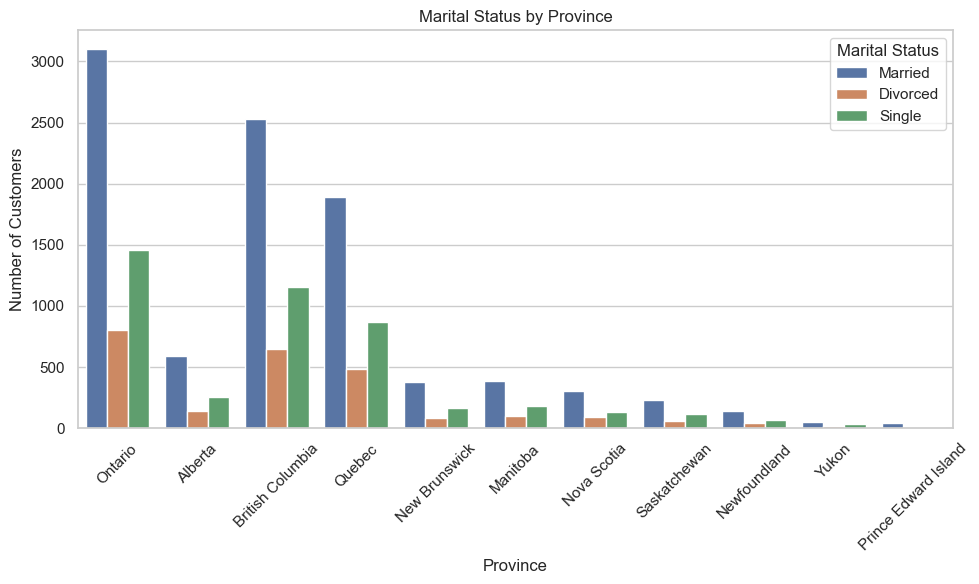

In [133]:
plt.figure(figsize=(10,6))
sns.countplot(data=dataset, x='Province or State', hue='Marital Status')
plt.title('Marital Status by Province')
plt.xlabel('Province')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Province vs LoyaltyStatus

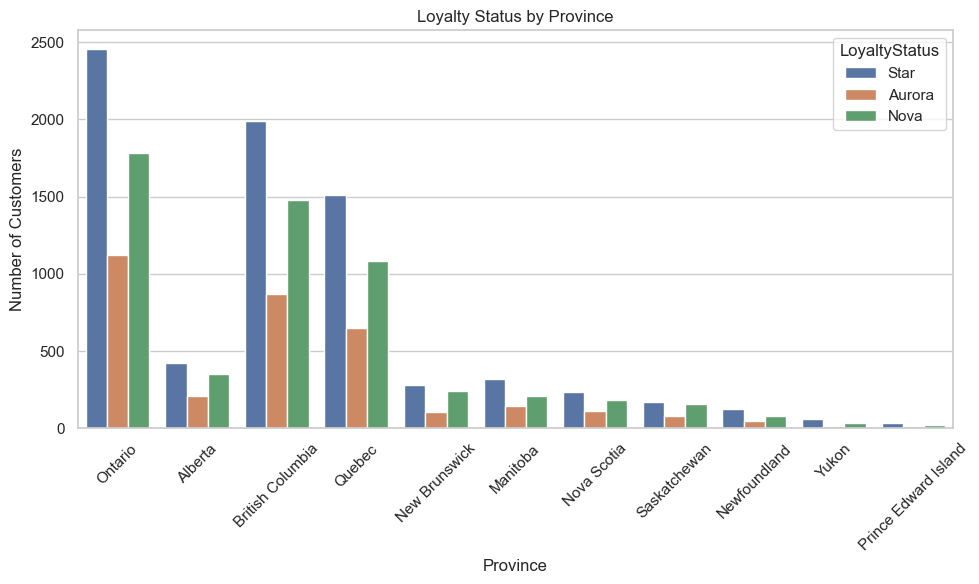

In [134]:
plt.figure(figsize=(10,6))
sns.countplot(data=dataset, x='Province or State', hue='LoyaltyStatus')
plt.title('Loyalty Status by Province')
plt.xlabel('Province')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Province vs Customer LifeTime Value (sum)

In [136]:
clv_sum = (
    dataset.groupby('Province or State')['Customer Lifetime Value']
    .sum()
    .reset_index(name='TotalCLV')
    .sort_values('TotalCLV', ascending=False)
)

fig = px.bar(
    clv_sum,
    x='Province or State',
    y='TotalCLV',
    title='Total Customer Lifetime Value by Province (Sum)',
    text_auto='.2s',
    color='TotalCLV',
    color_continuous_scale='Purples'
)
fig.update_layout(xaxis_title='Province', yaxis_title='Total CLV', height=500)
fig.show()

## Province vs Customer LifeTime Value (Mean)

In [138]:
clv_mean = (
    dataset.groupby('Province or State')['Customer Lifetime Value']
    .mean()
    .reset_index(name='AverageCLV')
    .sort_values('AverageCLV', ascending=False)
)

fig = px.bar(
    clv_mean,
    x='Province or State',
    y='AverageCLV',
    title='Average Customer Lifetime Value per Customer by Province',
    text_auto='.2f',
    color='AverageCLV',
    color_continuous_scale='Magma'
)
fig.update_layout(xaxis_title='Province', yaxis_title='Average CLV', height=500)
fig.show()

## Province vs IsActive (0 or 1)

In [139]:
active_counts = (
    dataset.groupby(['Province or State', 'IsActive'])
    .size()
    .reset_index(name='CustomerCount')
)

fig = px.bar(
    active_counts,
    x='Province or State',
    y='CustomerCount',
    color='IsActive',
    barmode='group',
    title='Active vs Inactive Customers by Province'
)
fig.update_layout(xaxis_title='Province', yaxis_title='Number of Customers', height=500)
fig.show()

## Province vs Total Flights

In [140]:
flights_sum = (
    dataset.groupby('Province or State')['total_flights']
    .sum()
    .reset_index(name='TotalFlights')
    .sort_values('TotalFlights', ascending=False)
)

fig = px.bar(
    flights_sum,
    x='Province or State',
    y='TotalFlights',
    title='Total Flights by Province',
    text_auto='.0f',
    color='TotalFlights',
    color_continuous_scale='Tealgrn'
)
fig.update_layout(xaxis_title='Province', yaxis_title='Total Flights', height=500)
fig.show()

## Province vs Total Distance

In [141]:
distance_sum = (
    dataset.groupby('Province or State')['total_distance']
    .sum()
    .reset_index(name='TotalDistance')
    .sort_values('TotalDistance', ascending=False)
)

fig = px.bar(
    distance_sum,
    x='Province or State',
    y='TotalDistance',
    title='Total Distance by Province',
    text_auto='.0f',
    color='TotalDistance',
    color_continuous_scale='Cividis'
)
fig.update_layout(xaxis_title='Province', yaxis_title='Total Distance (km)', height=500)
fig.show()


# Loyalty Status Analysis

In [35]:
# Frequencies and % share
for col in ["LoyaltyStatus", "IsActive", "EnrollmentType"]:
    print(f"\n=== {col} (counts) ===")
    print(dataset[col].value_counts(dropna=False))
    print(f"\n=== {col} (%) ===")
    print((dataset[col].value_counts(normalize=True, dropna=False) * 100).round(1))


=== LoyaltyStatus (counts) ===
LoyaltyStatus
Star      7598
Nova      5611
Aurora    3365
Name: count, dtype: int64

=== LoyaltyStatus (%) ===
LoyaltyStatus
Star      45.8
Nova      33.9
Aurora    20.3
Name: proportion, dtype: float64

=== IsActive (counts) ===
IsActive
1    14327
0     2247
Name: count, dtype: int64

=== IsActive (%) ===
IsActive
1    86.4
0    13.6
Name: proportion, dtype: float64

=== EnrollmentType (counts) ===
EnrollmentType
Standard          15436
2021 Promotion     1138
Name: count, dtype: int64

=== EnrollmentType (%) ===
EnrollmentType
Standard          93.1
2021 Promotion     6.9
Name: proportion, dtype: float64


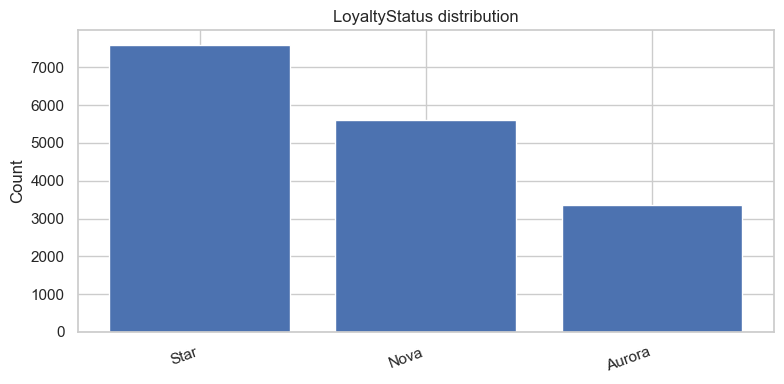

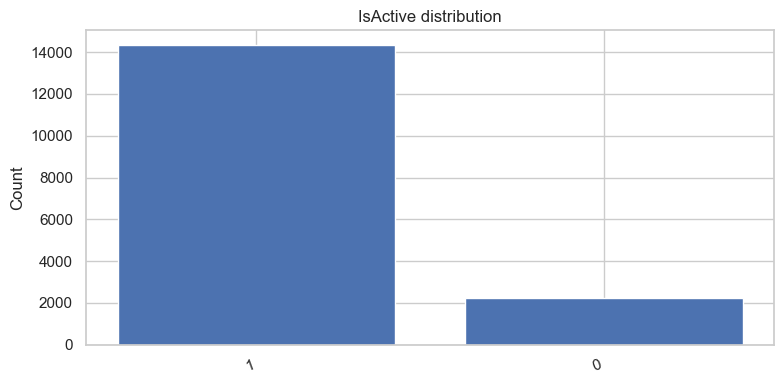

In [112]:
# Simple bar charts (one column at a time)

def bar_counts(df, col, top_n=None):
    counts = df[col].value_counts().head(top_n) if top_n else df[col].value_counts()
    plt.figure(figsize=(8,4))
    plt.bar(counts.index.astype(str), counts.values)
    plt.title(f"{col} distribution")
    plt.ylabel("Count"); plt.xticks(rotation=20, ha="right")
    plt.tight_layout(); plt.show()

bar_counts(dataset, "LoyaltyStatus")
bar_counts(dataset, "IsActive")

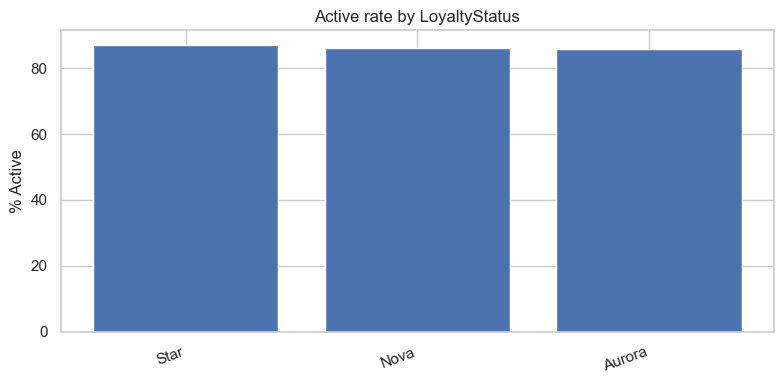

LoyaltyStatus
Star      87.1%
Nova      86.1%
Aurora    85.6%
Name: ActiveRate, dtype: object


In [37]:
# % Active by LoyaltyStatus (activation rate)

# If IsActive is booleans or {0,1}; coerce if needed
active_map = {True:1, False:0, "True":1, "False":0, "Y":1, "N":0, 1:1, 0:0}
tmp = dataset.copy()
tmp["IsActive_num"] = tmp["IsActive"].map(active_map)

active_rate = (
    tmp.groupby("LoyaltyStatus")["IsActive_num"]
       .mean()
       .sort_values(ascending=False)
       .rename("ActiveRate")
)

plt.figure(figsize=(8,4))
plt.bar(active_rate.index.astype(str), (active_rate.values*100))
plt.title("Active rate by LoyaltyStatus")
plt.ylabel("% Active"); plt.xticks(rotation=20, ha="right")
plt.tight_layout(); plt.show()

print(active_rate.mul(100).round(1).astype(str) + "%")

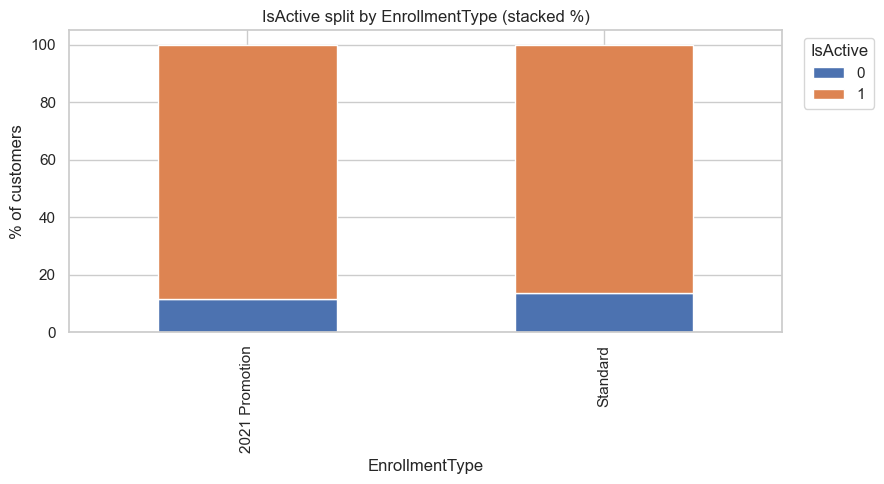


% breakdown by EnrollmentType:
IsActive           0     1
EnrollmentType            
2021 Promotion  11.7  88.3
Standard        13.7  86.3


In [38]:
# Stacked % bar: EnrollmentType × IsActive

ct = pd.crosstab(dataset["EnrollmentType"], dataset["IsActive"])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

# Plot stacked %
ax = ct_pct.plot(kind="bar", stacked=True, figsize=(9,5))
ax.set_title("IsActive split by EnrollmentType (stacked %)")
ax.set_ylabel("% of customers"); ax.set_xlabel("EnrollmentType")
ax.legend(title="IsActive", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()

print("\n% breakdown by EnrollmentType:")
print(ct_pct.round(1))

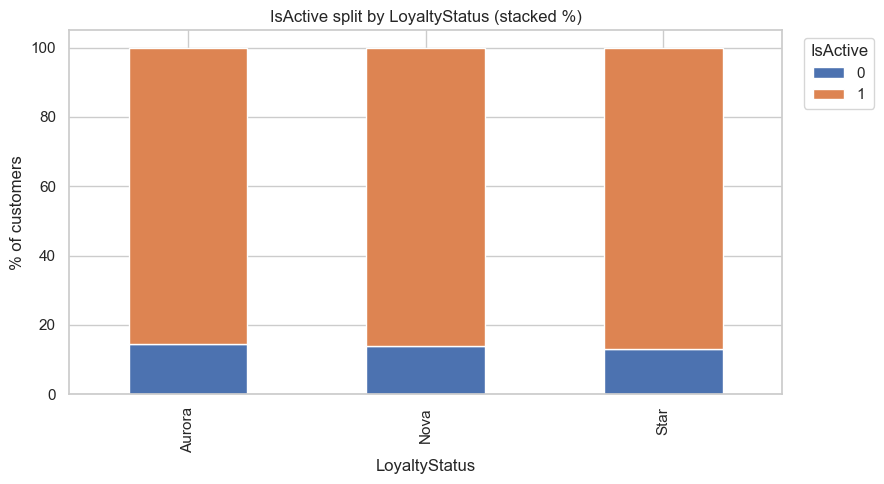


% breakdown by LoyaltyStatus:
IsActive          0     1
LoyaltyStatus            
Aurora         14.4  85.6
Nova           13.9  86.1
Star           12.9  87.1


In [39]:
# Stacked % bar: LoyaltyStatus × IsActive

ct2 = pd.crosstab(dataset["LoyaltyStatus"], dataset["IsActive"])
ct2_pct = ct2.div(ct2.sum(axis=1), axis=0) * 100

ax = ct2_pct.plot(kind="bar", stacked=True, figsize=(9,5))
ax.set_title("IsActive split by LoyaltyStatus (stacked %)")
ax.set_ylabel("% of customers"); ax.set_xlabel("LoyaltyStatus")
ax.legend(title="IsActive", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()

print("\n% breakdown by LoyaltyStatus:")
print(ct2_pct.round(1))

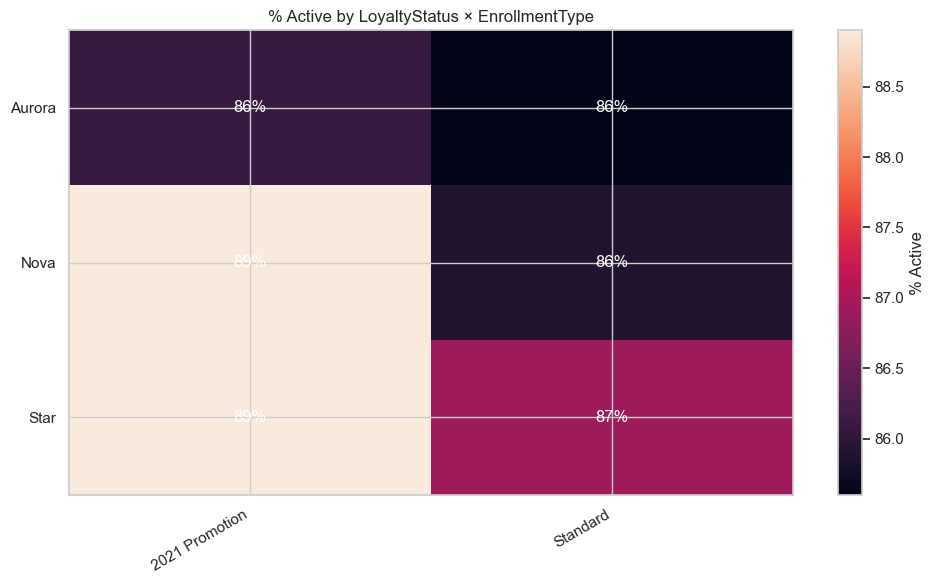


% Active (table):
EnrollmentType  2021 Promotion  Standard
LoyaltyStatus                           
Aurora                    86.1      85.6
Nova                      88.9      85.9
Star                      88.9      86.9


In [40]:
# Heatmap (matplotlib) of % Active for (LoyaltyStatus × EnrollmentType)

# Build % active pivot
active_map = {True:1, False:0, "True":1, "False":0, "Y":1, "N":0, 1:1, 0:0}
df = dataset.copy()
df["IsActive_num"] = df["IsActive"].map(active_map)

pivot = (
    df.pivot_table(
        index="LoyaltyStatus",
        columns="EnrollmentType",
        values="IsActive_num",
        aggfunc="mean"
    ) * 100
).round(1)

fig, ax = plt.subplots(figsize=(10,6))
im = ax.imshow(pivot.values, aspect="auto")

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("% Active", rotation=90)

# Ticks and labels
ax.set_xticks(np.arange(len(pivot.columns)))
ax.set_yticks(np.arange(len(pivot.index)))
ax.set_xticklabels(pivot.columns, rotation=30, ha="right")
ax.set_yticklabels(pivot.index)
ax.set_title("% Active by LoyaltyStatus × EnrollmentType")

# Annotate cells
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        if pd.notnull(val):
            ax.text(j, i, f"{val:.0f}%", ha="center", va="center", color="white" if val>=50 else "black")

plt.tight_layout(); plt.show()

print("\n% Active (table):")
print(pivot)

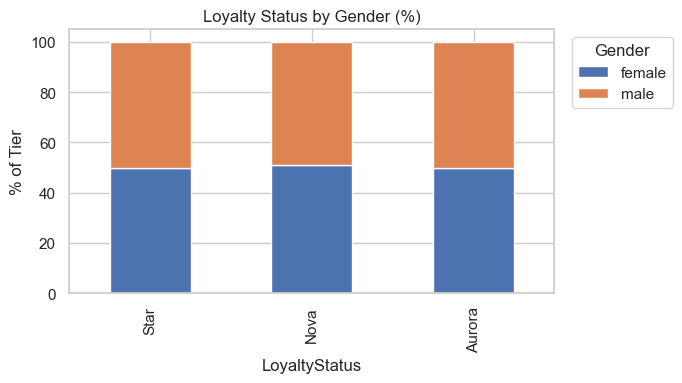

In [44]:
# loyalty status by gender

if set(["LoyaltyStatus","Gender"]).issubset(dataset.columns):
    ctab = pd.crosstab(dataset["LoyaltyStatus"], dataset["Gender"], normalize="index") * 100
    ctab = ctab.loc[dataset["LoyaltyStatus"].value_counts().index]  # order tiers by size
    ax = ctab.plot(kind="bar", stacked=True, figsize=(7,4))
    plt.title("Loyalty Status by Gender (%)")
    plt.ylabel("% of Tier")
    plt.xlabel("LoyaltyStatus")
    plt.legend(title="Gender", bbox_to_anchor=(1.02,1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("LoyaltyStatus and/or Gender columns not found.")

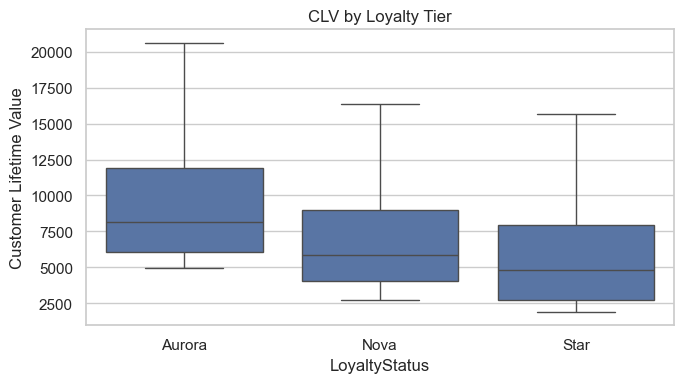

In [45]:
# CLV by LoyaltyStatus

if set(["Customer Lifetime Value","LoyaltyStatus"]).issubset(dataset.columns):
    order = (dataset.groupby("LoyaltyStatus")["Customer Lifetime Value"]
             .median().sort_values(ascending=False).index)
    plt.figure(figsize=(7,4))
    sns.boxplot(data=dataset, x="LoyaltyStatus", y="Customer Lifetime Value",
                order=order, showfliers=False)
    plt.title("CLV by Loyalty Tier")
    plt.xlabel("LoyaltyStatus")
    plt.ylabel("Customer Lifetime Value")
    plt.tight_layout()
    plt.show()
else:
    print("Customer Lifetime Value and/or LoyaltyStatus columns not found.")

# Customer Tenure days Analysis

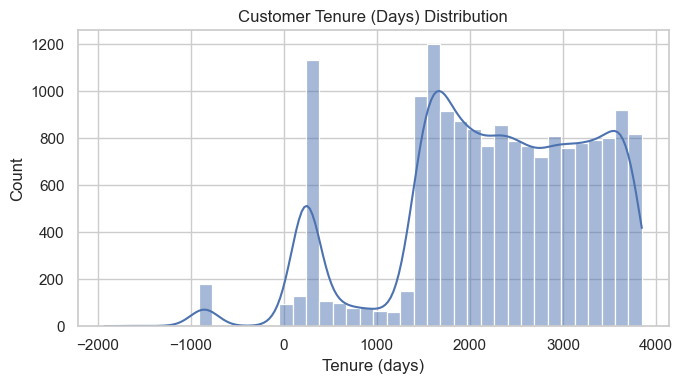

In [46]:
# Customer tenure distibution

if "CustomerTenureDays" in dataset.columns:
    plt.figure(figsize=(7,4))
    sns.histplot(dataset["CustomerTenureDays"].dropna(), bins=40, kde=True)
    plt.title("Customer Tenure (Days) Distribution")
    plt.xlabel("Tenure (days)")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
else:
    print("CustomerTenureDays column not found.")

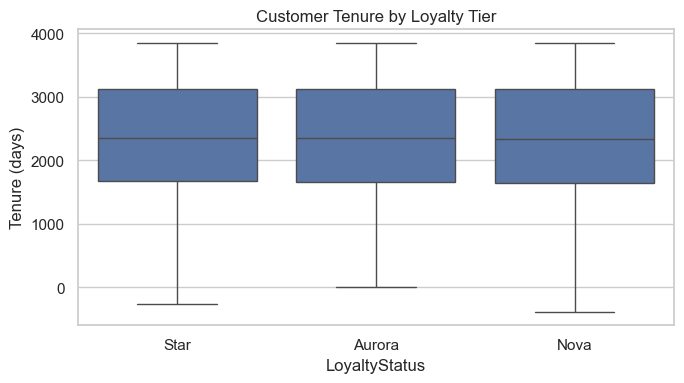

In [47]:
# Tenure by LoyaltyStatus

if set(["CustomerTenureDays","LoyaltyStatus"]).issubset(dataset.columns):
    order = (dataset.groupby("LoyaltyStatus")["CustomerTenureDays"]
             .median().sort_values(ascending=False).index)
    plt.figure(figsize=(7,4))
    sns.boxplot(data=dataset, x="LoyaltyStatus", y="CustomerTenureDays",
                order=order, showfliers=False)
    plt.title("Customer Tenure by Loyalty Tier")
    plt.xlabel("LoyaltyStatus")
    plt.ylabel("Tenure (days)")
    plt.tight_layout()
    plt.show()
else:
    print("CustomerTenureDays and/or LoyaltyStatus columns not found.")